# Market Sentiment — Time Series Analysis Project
**Pipeline:** Data Cleaning → Feature Engineering → PCA Sentiment Index → Full Time Series Analysis

---
# PART 1 — Data Cleaning & Sentiment Score Construction

In [112]:
import pandas as pd 
import numpy as np

In [113]:
df = pd.read_csv('master_market_data_2010_2026.csv' , parse_dates=['date'])
df.head()
display(df.isna().sum())

date                   0
nifty50_open         253
nifty50_high         253
nifty50_low          253
nifty50_close        253
                    ... 
bhartiartl_open      232
bhartiartl_high      232
bhartiartl_low       232
bhartiartl_close     232
bhartiartl_volume    232
Length: 76, dtype: int64

In [114]:

# Forward-Fill missing values (The Imputation)
df = df.ffill()
# Backward-Fill missing values (The Imputation)
df = df.bfill()
display(df.isna().sum())

date                 0
nifty50_open         0
nifty50_high         0
nifty50_low          0
nifty50_close        0
                    ..
bhartiartl_open      0
bhartiartl_high      0
bhartiartl_low       0
bhartiartl_close     0
bhartiartl_volume    0
Length: 76, dtype: int64

In [115]:
ASSETS = sorted({c.rsplit('_', 1)[0] for c in df.columns if c.endswith('_close')})
print('Assets detected:', ASSETS)

Assets detected: ['bhartiartl', 'brent', 'gold', 'hdfcbank', 'icicibank', 'infy', 'itc', 'lt', 'nifty50', 'reliance', 'sbin', 'sp500', 'sunpharma', 'tcs', 'usd_inr']


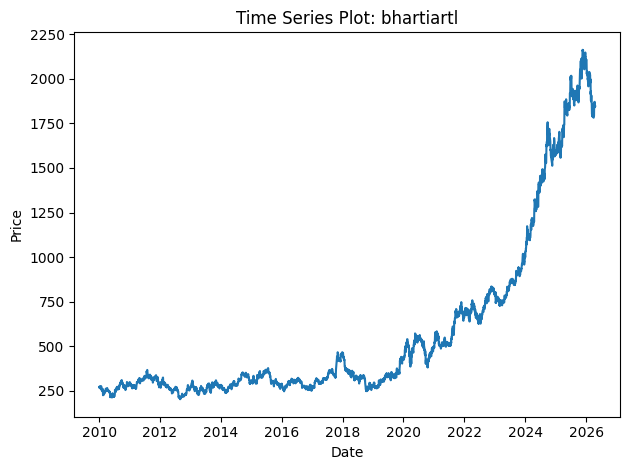

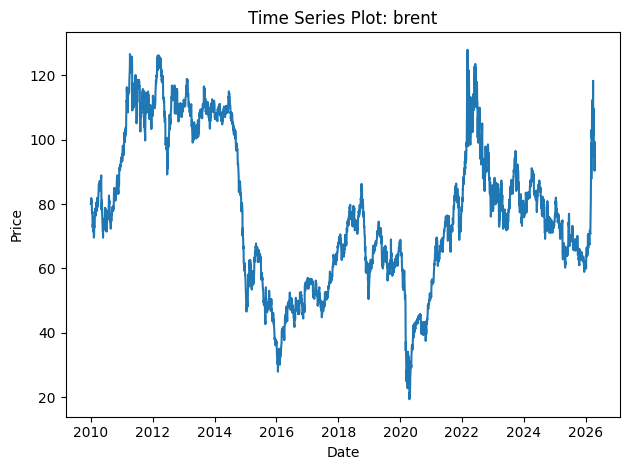

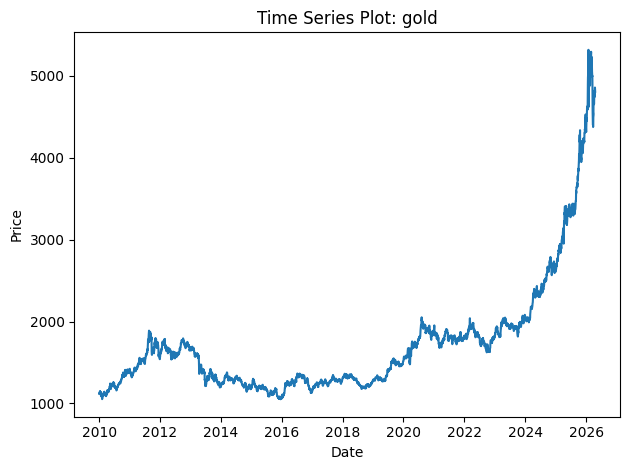

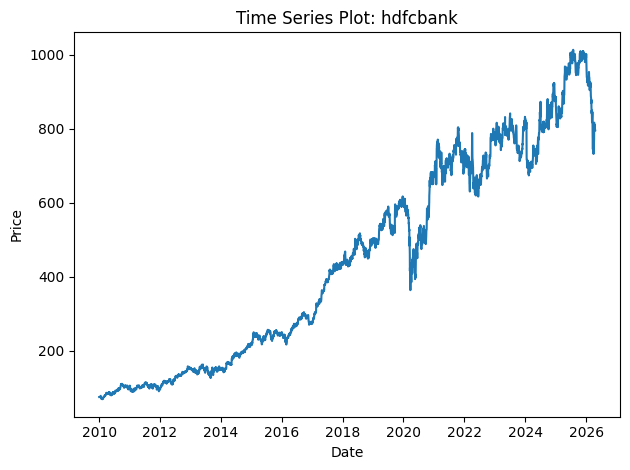

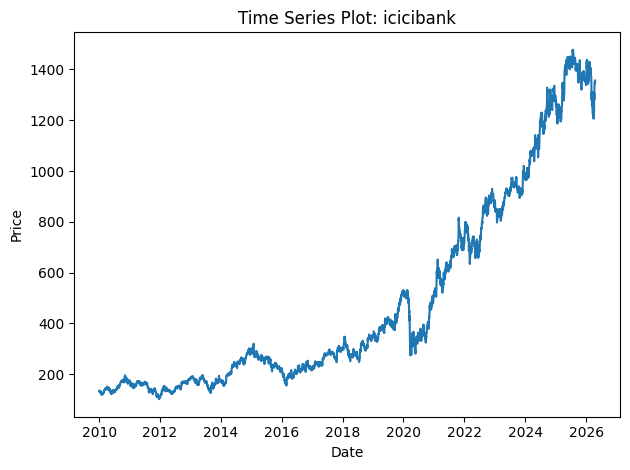

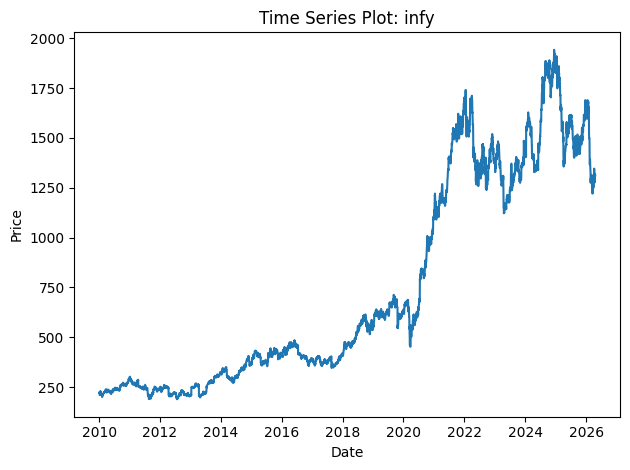

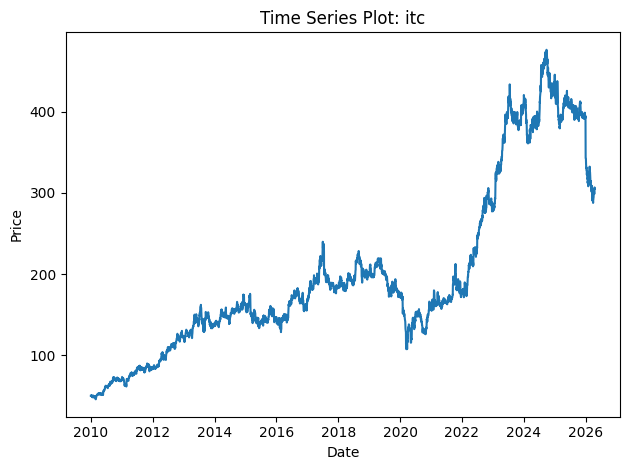

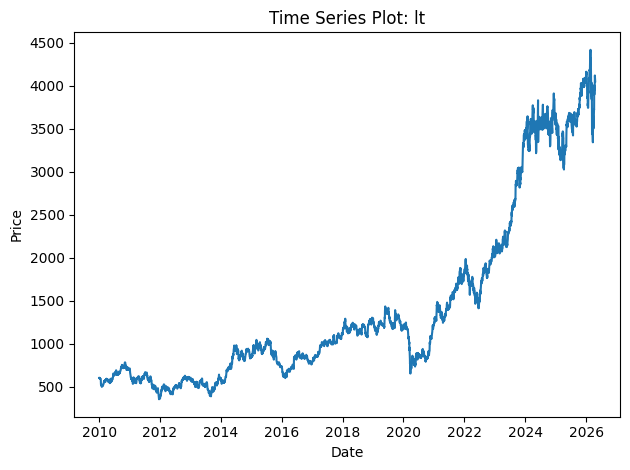

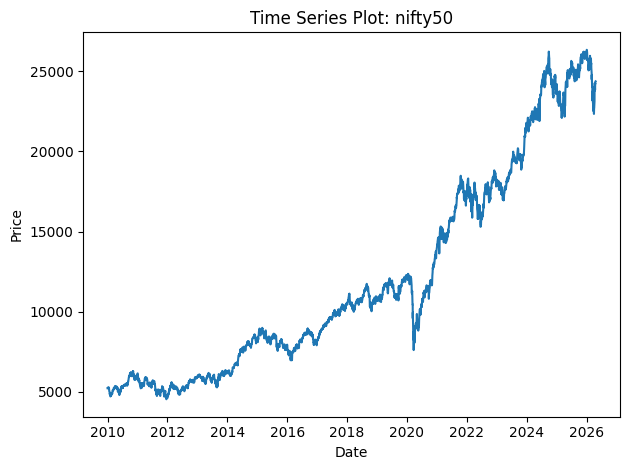

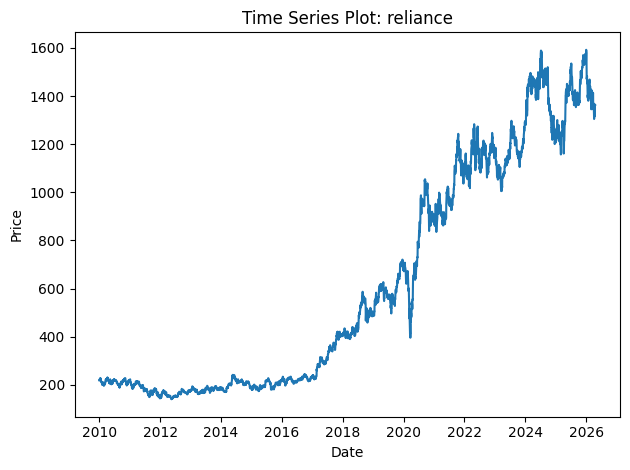

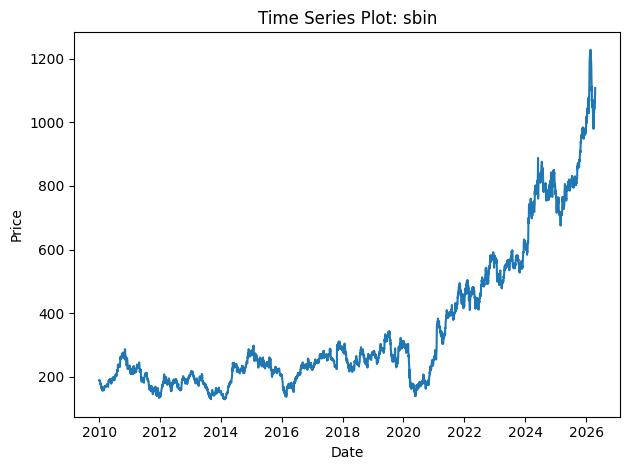

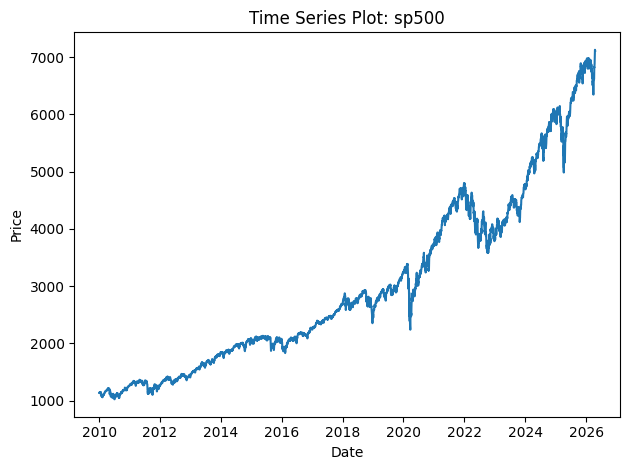

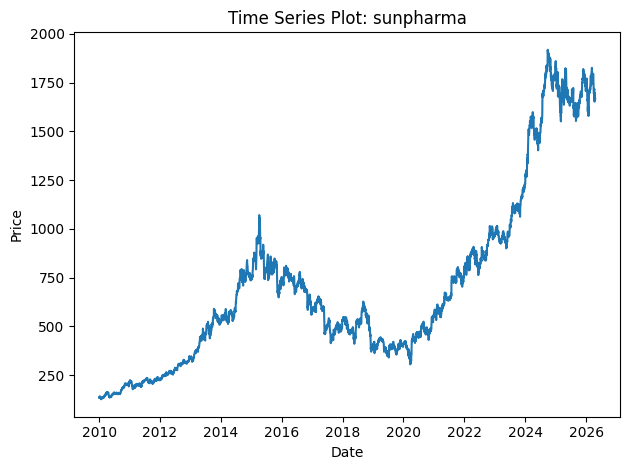

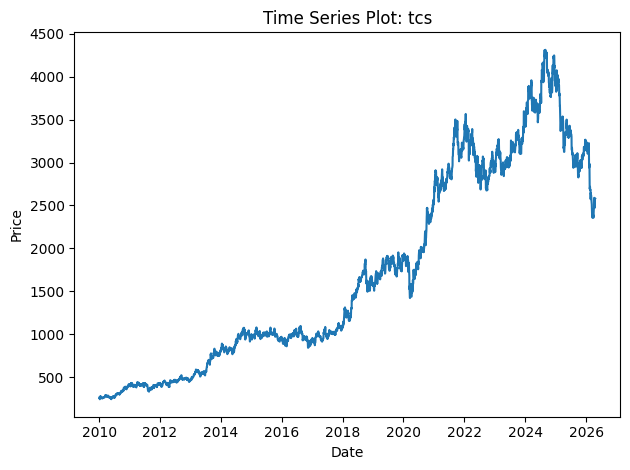

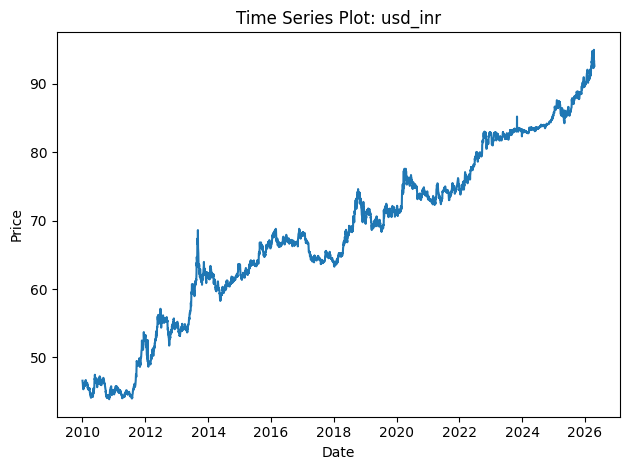

In [116]:
import matplotlib.pyplot as plt

for col in ASSETS:
    plt.plot(df['date'], df[f'{col}_close'], color='tab:blue')
    
    plt.title(f'Time Series Plot: {col}')
    plt.xlabel('Date')
    plt.ylabel('Price')
    
    plt.tight_layout()
    plt.show()

In [117]:
for asset in ASSETS:
    close = f'{asset}_close'
    high  = f'{asset}_high'
    low   = f'{asset}_low'
    open = f'{asset}_open'

    # Log return: lag-1 difference of log prices
    if close in df.columns:
        df[f'{asset}_return'] = np.log(df[close] / df[close].shift(1))

    # Volatility proxy: (High - Low) / Open
    if all(c in df.columns for c in [high, low, open]):
        df[f'{asset}_volatility'] = (df[high] - df[low]) / df[open]

df = df.dropna()   # drop first row created by shift(1)
display(df.head(3))

,date,nifty50_open,nifty50_high,nifty50_low,nifty50_close,nifty50_volume,sp500_open,sp500_high,sp500_low,sp500_close,...,sbin_return,sbin_volatility,sp500_return,sp500_volatility,sunpharma_return,sunpharma_volatility,tcs_return,tcs_volatility,usd_inr_return,usd_inr_volatility
1,2010-01-04,5200.899902,5238.450195,5167.100098,5232.200195,0.0,1116.560059,1133.869995,1116.560059,1132.989990,...,0.000000,0.010989,0.000000,0.015503,0.000000,0.023992,0.000000,0.013050,-0.006932,0.008303
2,2010-01-05,5277.149902,5288.350098,5242.399902,5277.899902,0.0,1132.660034,1136.630005,1129.660034,1136.520020,...,0.000371,0.012955,0.003111,0.006154,0.029610,0.030059,0.000266,0.017219,-0.003636,0.004321
3,2010-01-06,5278.149902,5310.850098,5260.049805,5281.799805,0.0,1135.709961,1139.189941,1133.949951,1137.140015,...,0.005981,0.013061,0.000545,0.004614,0.012894,0.031767,-0.022871,0.025537,-0.008711,0.010401


In [118]:
# Select only the engineered return & volatility columns
return_cols     = [f'{a}_return'     for a in ASSETS if f'{a}_return'     in df.columns]
volatility_cols = [f'{a}_volatility' for a in ASSETS if f'{a}_volatility' in df.columns]
FEATURES = return_cols + volatility_cols

dates = df['date'] 
df = df[FEATURES]
display(df.head(3))

,bhartiartl_return,brent_return,gold_return,hdfcbank_return,icicibank_return,infy_return,itc_return,lt_return,nifty50_return,reliance_return,...,infy_volatility,itc_volatility,lt_volatility,nifty50_volatility,reliance_volatility,sbin_volatility,sp500_volatility,sunpharma_volatility,tcs_volatility,usd_inr_volatility
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.013295,0.018379,0.008229,0.013719,0.063468,0.010989,0.015503,0.023992,0.013050,0.008303
2,0.015712,0.005849,0.000358,0.000879,0.009447,0.003344,0.009808,0.001772,0.008696,-0.004473,...,0.011679,0.015895,0.015396,0.008707,0.073485,0.012955,0.006154,0.030059,0.017219,0.004321
3,-0.010651,0.016002,0.015795,0.000673,0.007628,-0.014699,0.002339,-0.011127,0.000739,0.016029,...,0.040216,0.019714,0.029586,0.009625,0.022085,0.013061,0.004614,0.031767,0.025537,0.010401


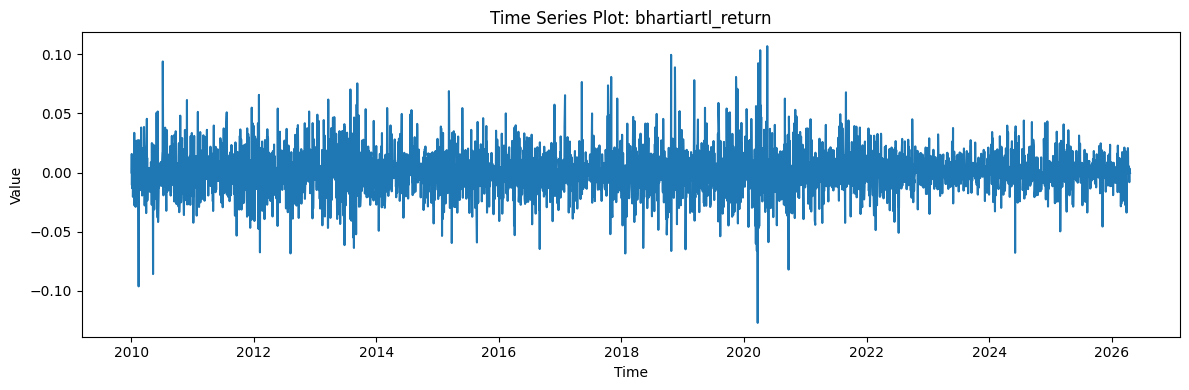

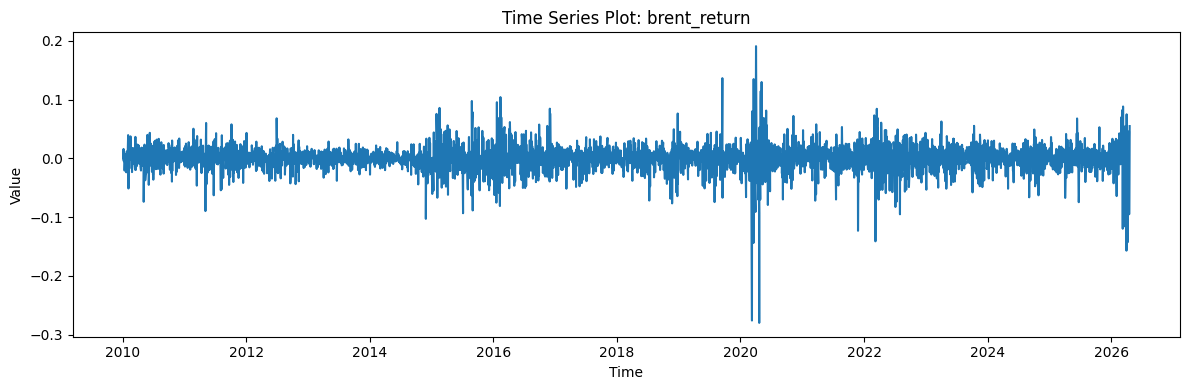

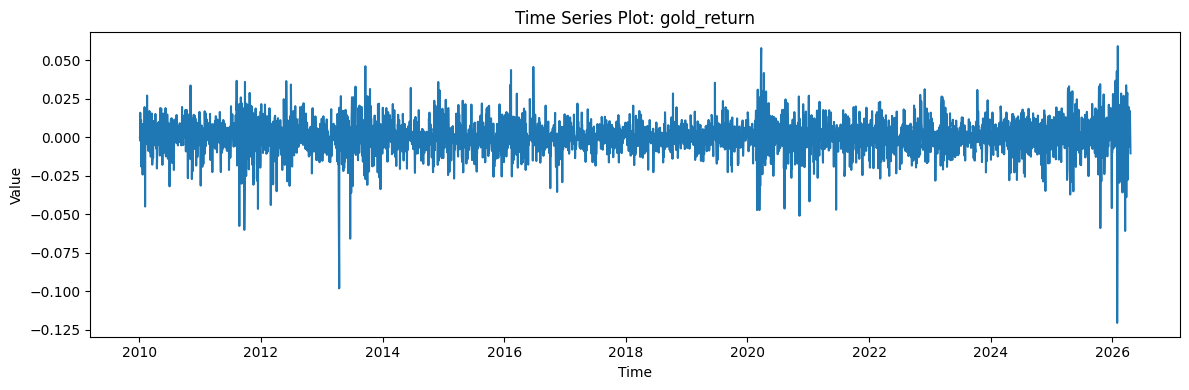

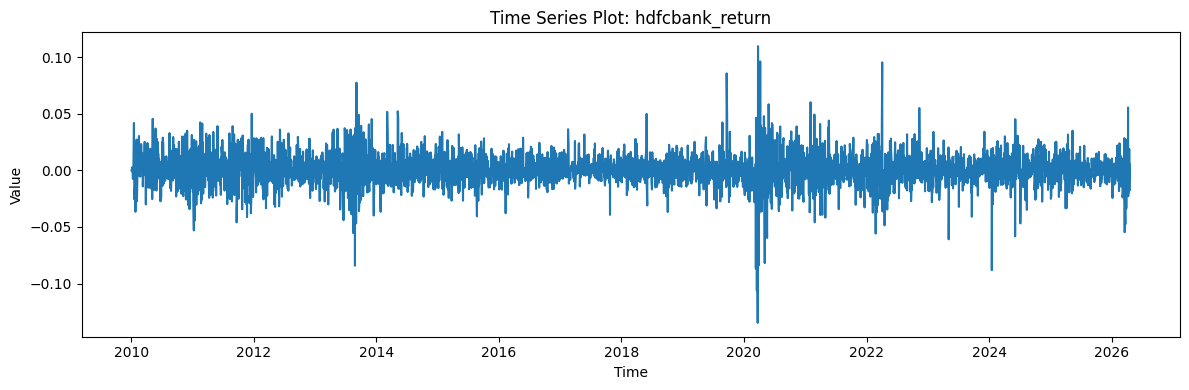

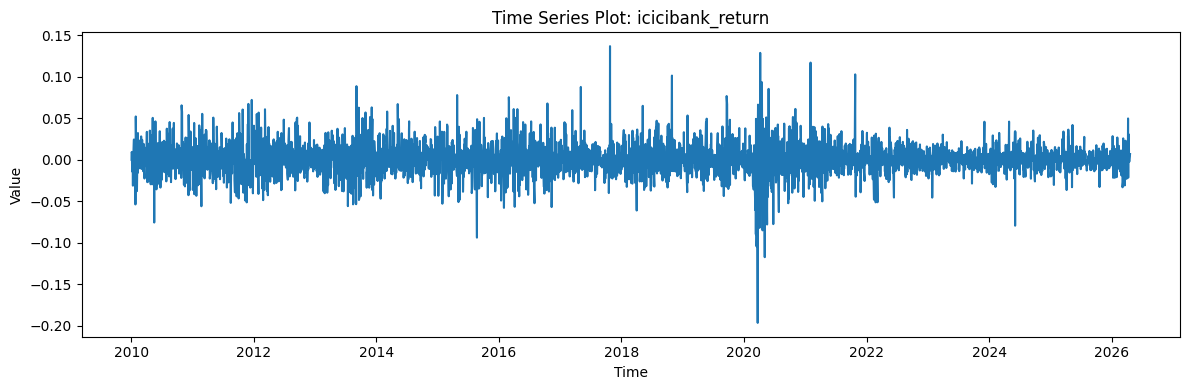

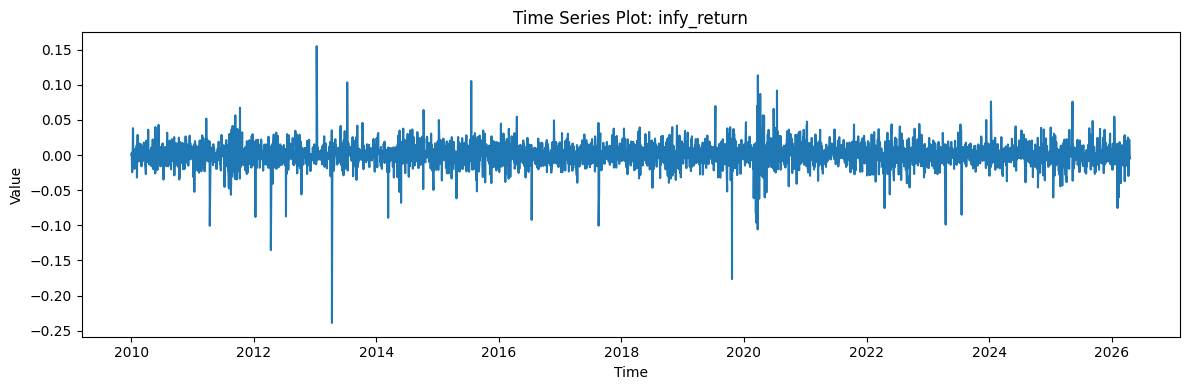

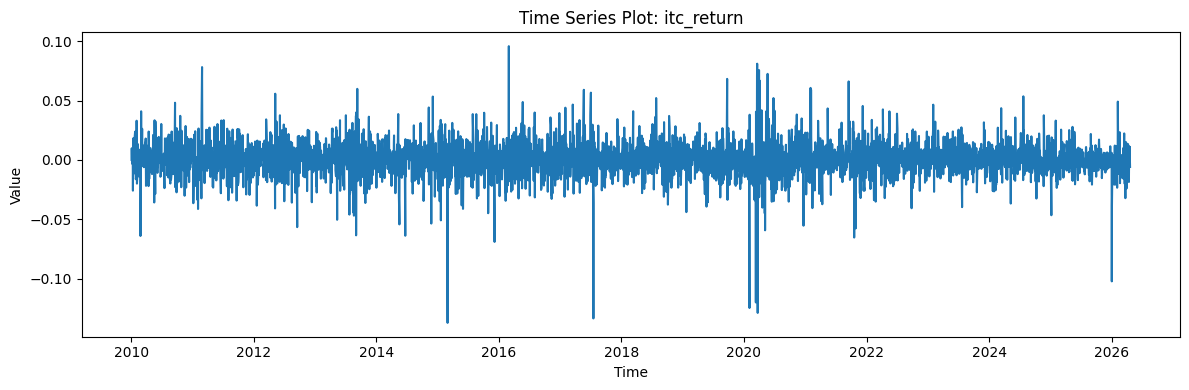

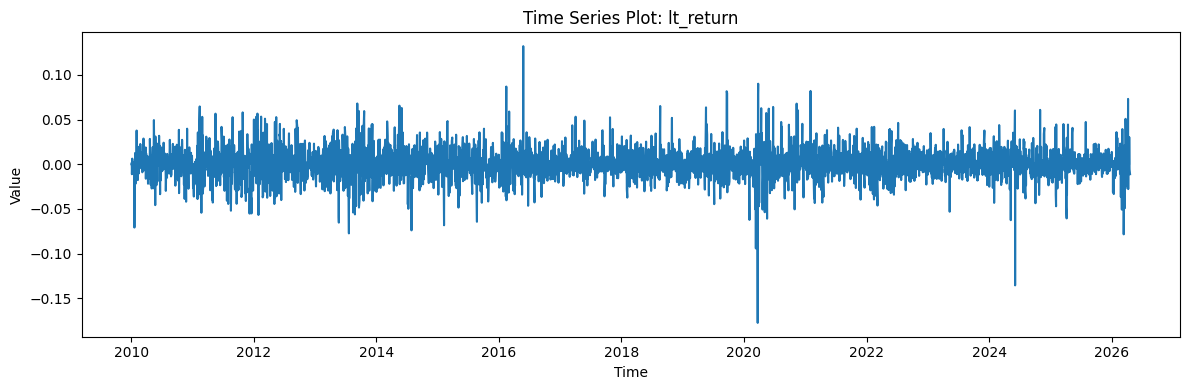

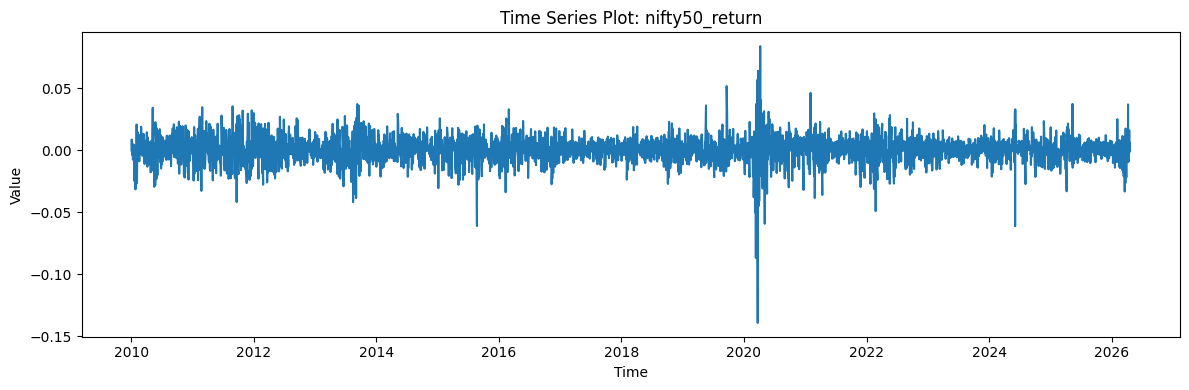

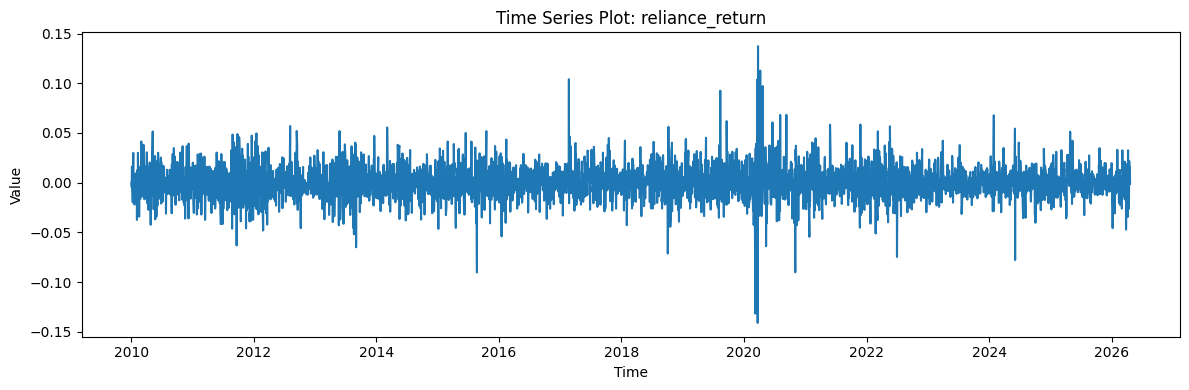

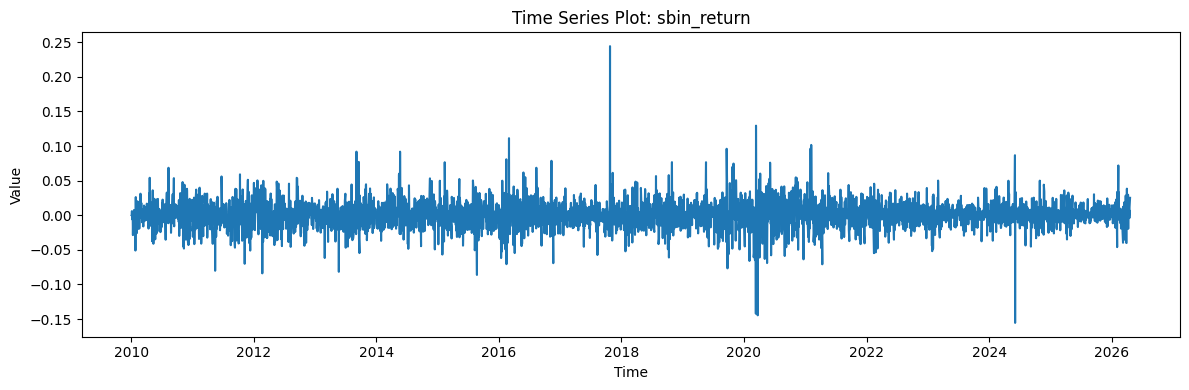

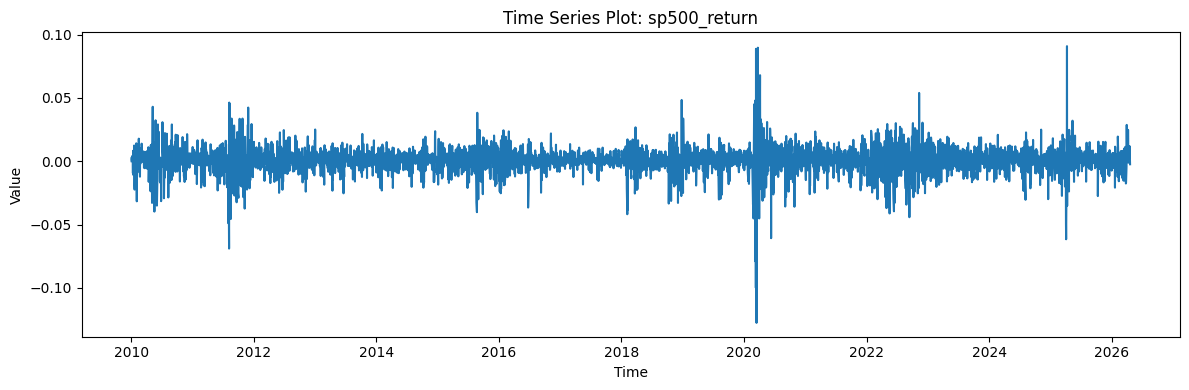

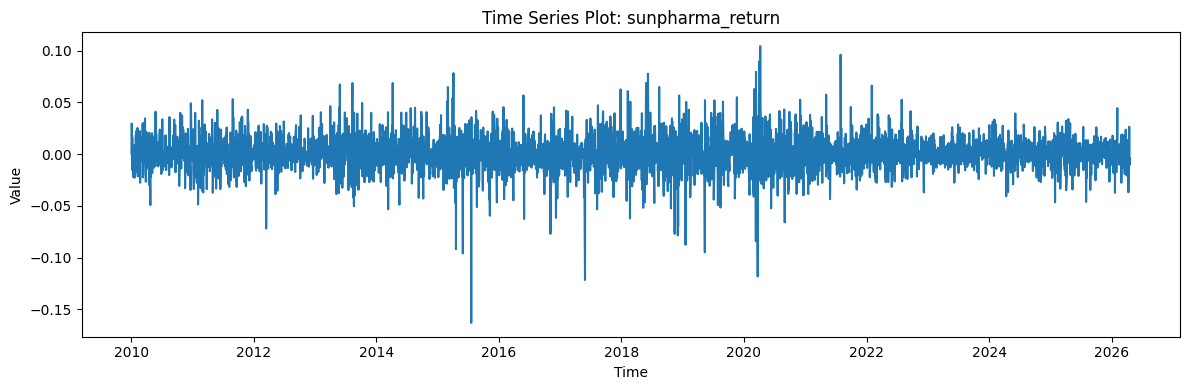

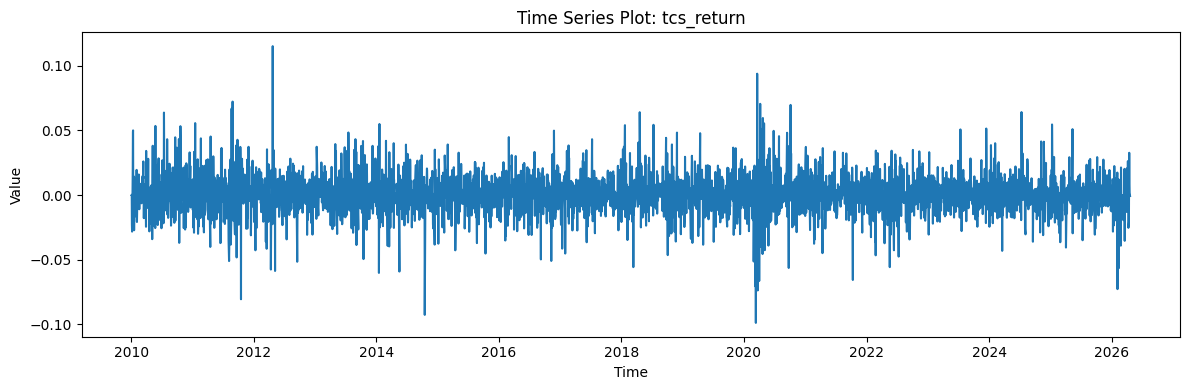

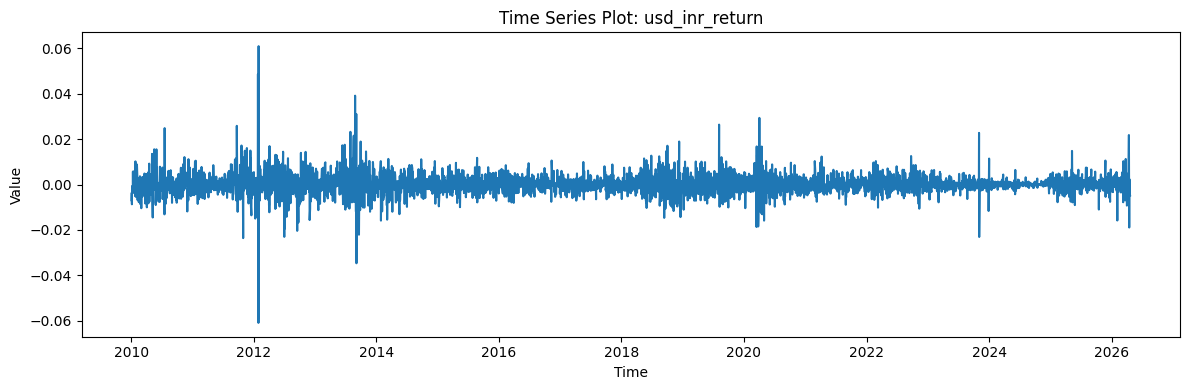

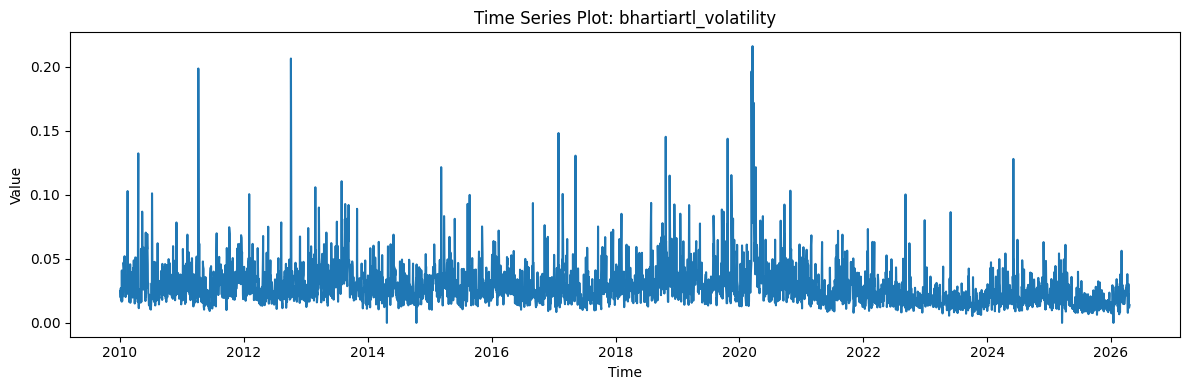

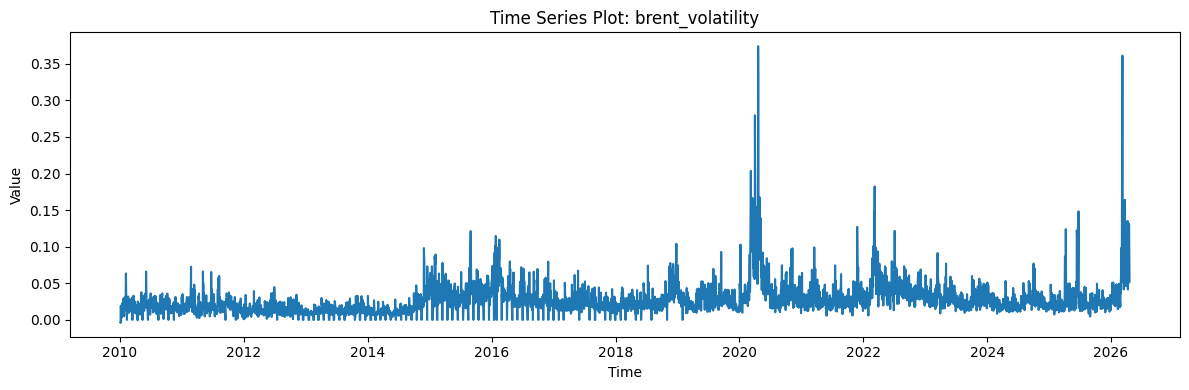

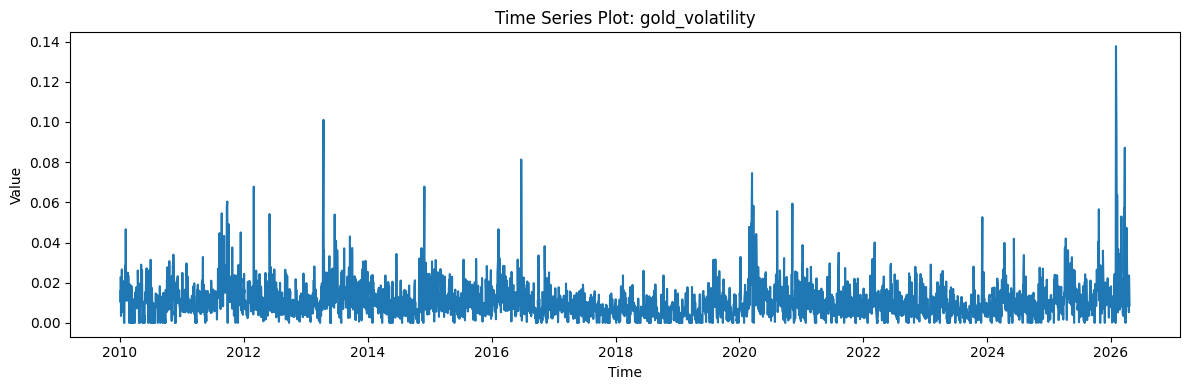

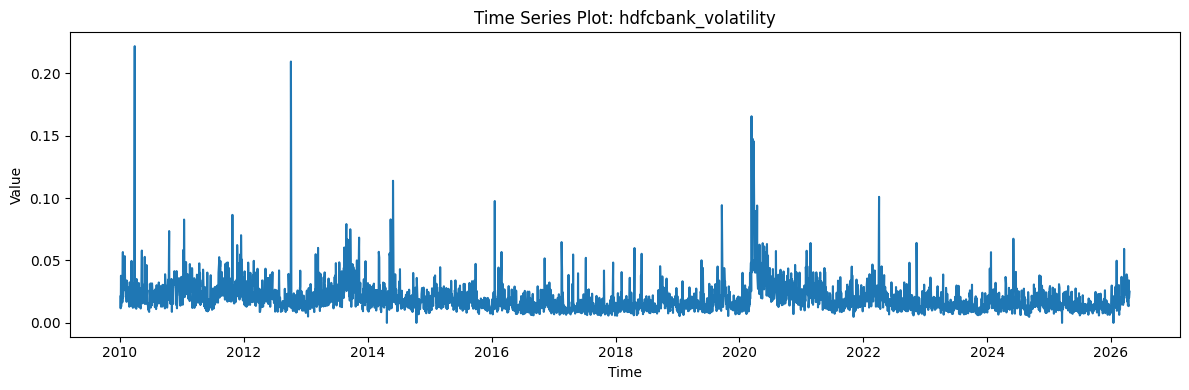

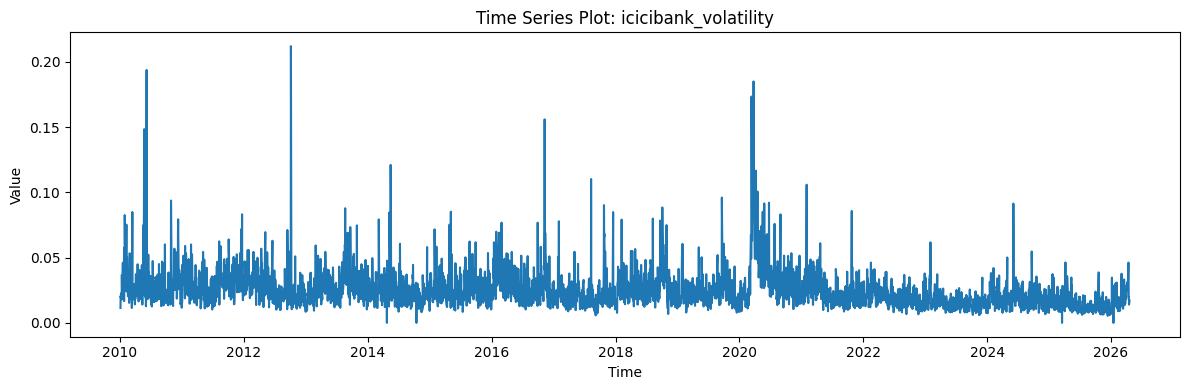

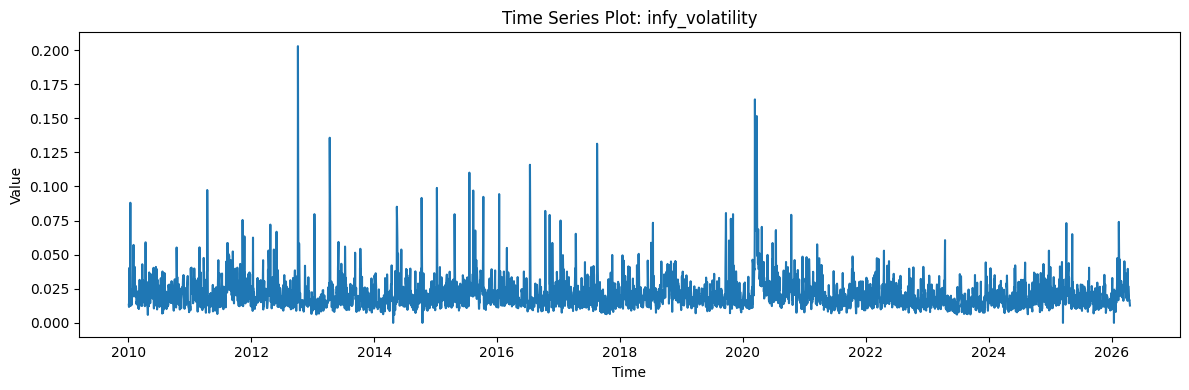

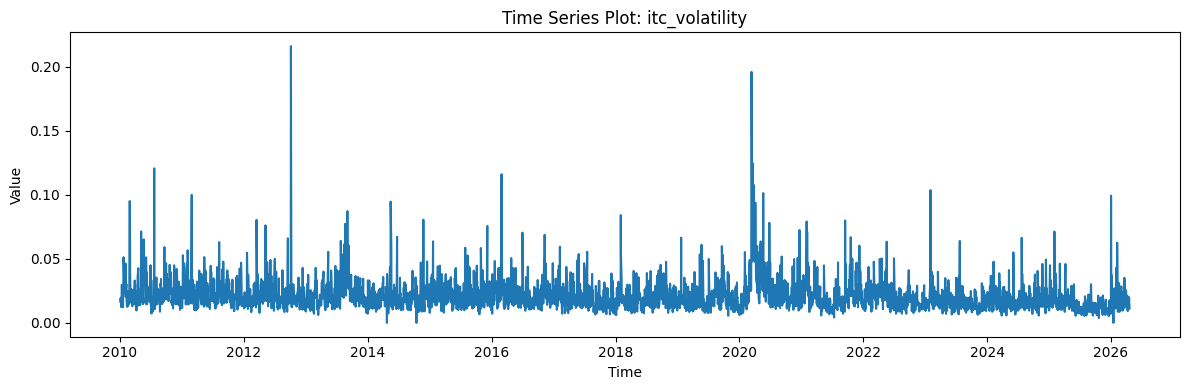

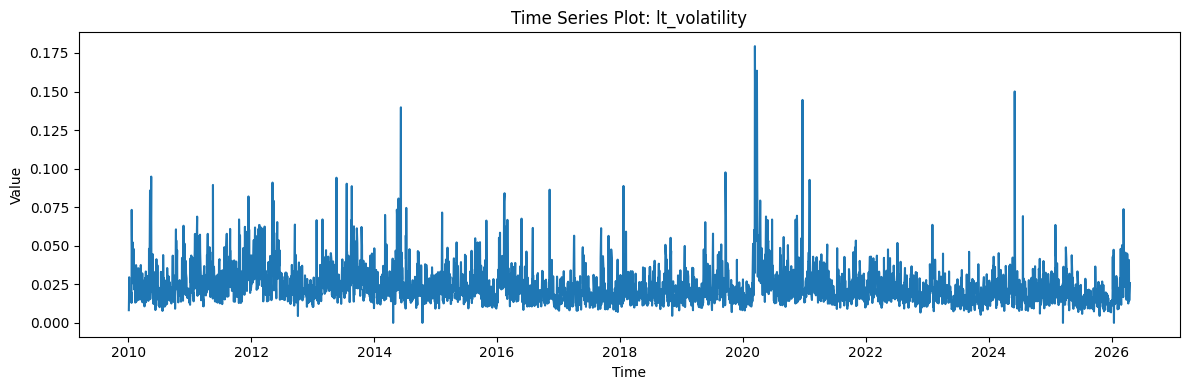

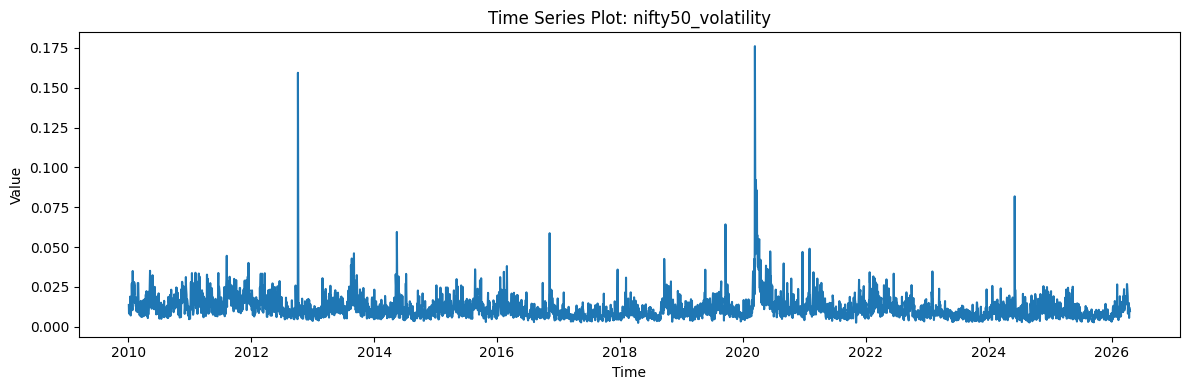

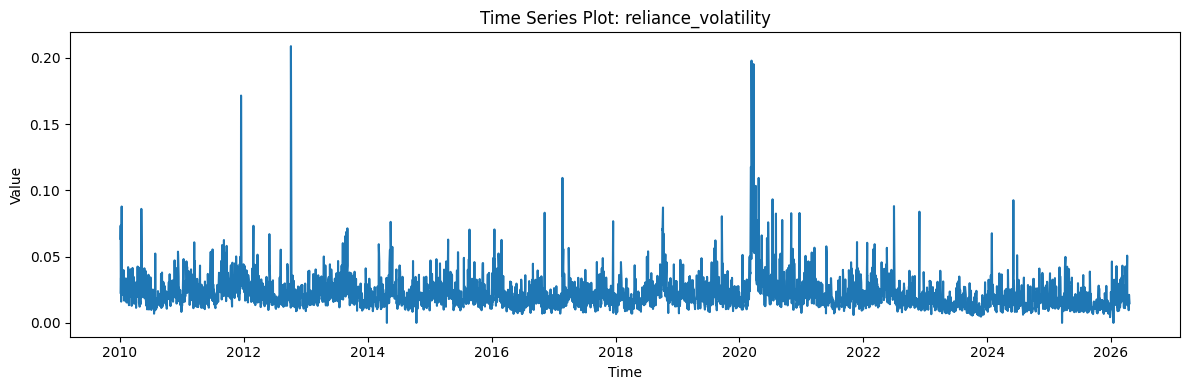

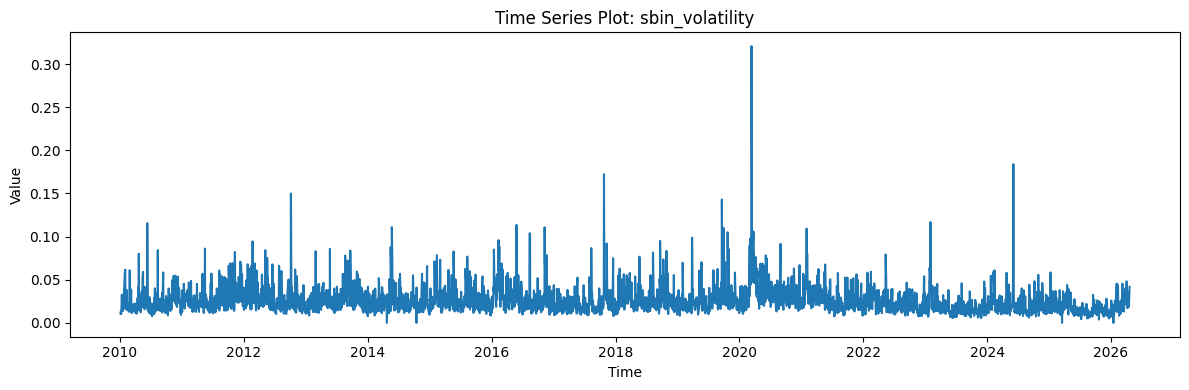

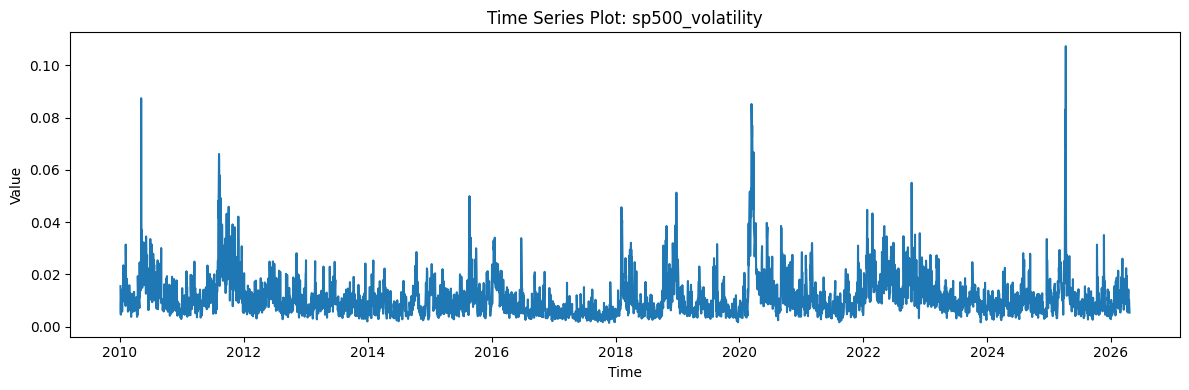

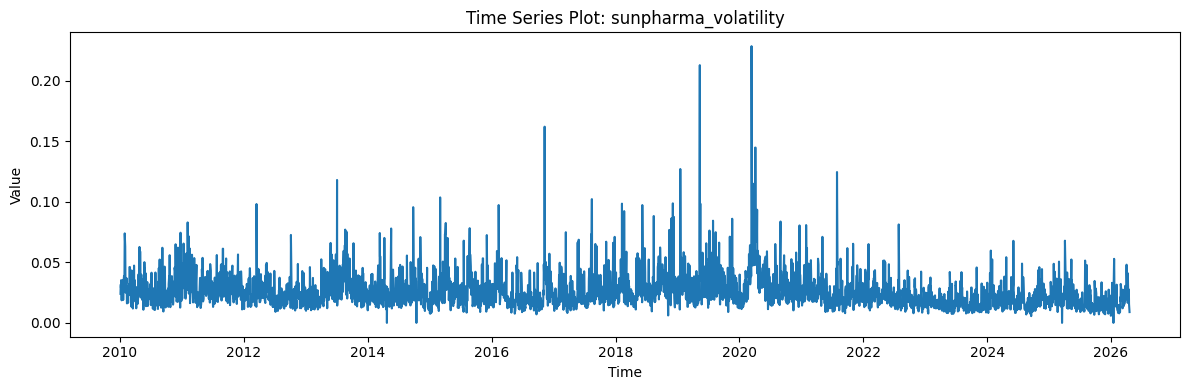

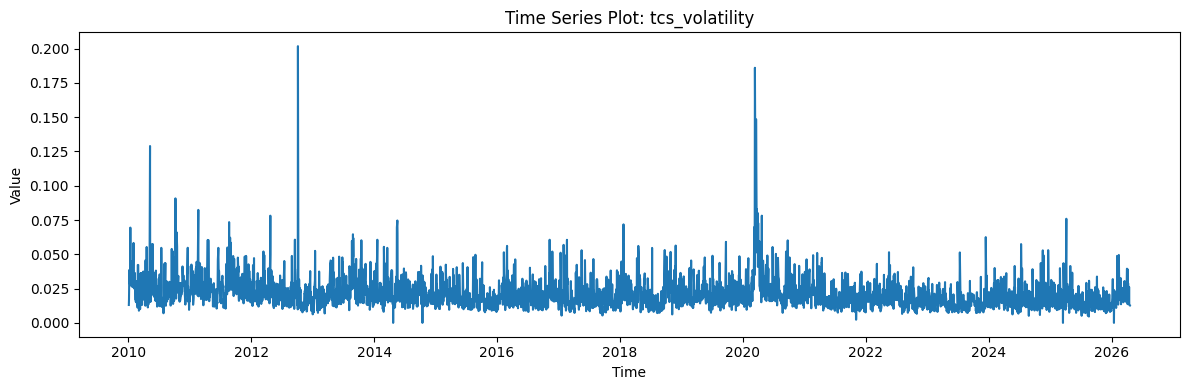

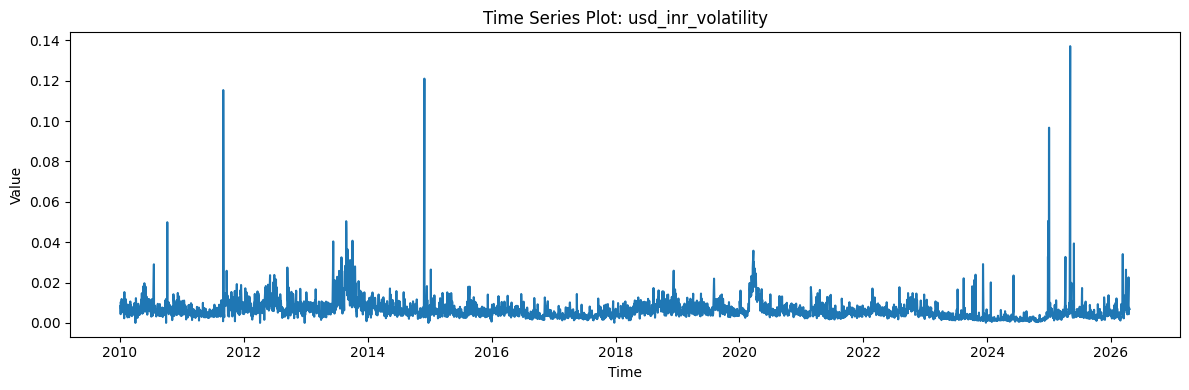

In [119]:

for col in FEATURES:
    plt.figure(figsize=(12, 4)) 
    plt.plot(dates, df[col], color='tab:blue')
    
    # Corrected Pyplot commands
    plt.title(f'Time Series Plot: {col}') 
    plt.xlabel('Time')
    plt.ylabel('Value')
    
    plt.tight_layout()
    plt.show()

In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df = scaler.fit_transform(df)

display(df[:5])

array([[-2.46855670e-02, -1.82477963e-03, -3.26246280e-02,
        -3.94798166e-02, -2.88154248e-02, -2.50294880e-02,
        -2.87545466e-02, -2.58377100e-02, -3.56440061e-02,
        -2.61317221e-02, -2.11200090e-02, -4.03269823e-02,
        -3.50298495e-02, -3.56943181e-02, -1.49147195e+00,
        -2.05674355e-01, -1.41730700e+00,  1.37070121e+00,
         1.15618480e-01, -9.21628192e-01, -6.37227776e-01,
        -2.29506945e-01, -1.20372845e+00,  2.50782066e-01,
         3.29585205e+00, -9.65279165e-01,  5.44270338e-01,
        -1.41934382e-01, -7.39092967e-01,  3.29226138e-01],
       [ 8.33330218e-01,  2.56922579e-01,  1.40453992e-03,
         2.29916649e-02,  4.70219392e-01,  1.75302643e-01,
         6.31980516e-01,  7.64452576e-02,  8.21147798e-01,
        -2.97644003e-01, -2.30082008e-03,  2.50121826e-01,
         1.71524160e+00, -1.80094336e-02, -7.98415268e-01,
        -5.28717605e-01, -1.43320326e+00, -2.29349464e-02,
        -6.50536682e-01, -3.01412414e-01, -7.74142777e-

In [121]:

from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

# Assuming 'df_scaled_dataframe' is your standardized dataset of the 8 stationary variables
chi_square_value, p_value = calculate_bartlett_sphericity(df)

print("-- Bartlett's Test of Sphericity Results ")
print(f"Chi-Square Value: {chi_square_value:.4f}")
print(f"P-value: {p_value:.4e}") # Using scientific notation for very small p-values

if p_value < 0.05:
    print("We reject the Null Hypothesis (H0) in favor of H1.")
    print("The correlation matrix is mathematically proven to NOT be an identity matrix.")
else:
    print("We fail to reject the Null Hypothesis (H0).")
    print("The correlation matrix is statistically indistinguishable from an identity matrix.")

-- Bartlett's Test of Sphericity Results 
Chi-Square Value: 49588.7491
P-value: 0.0000e+00
We reject the Null Hypothesis (H0) in favor of H1.
The correlation matrix is mathematically proven to NOT be an identity matrix.


In [122]:

from factor_analyzer.factor_analyzer import calculate_kmo


kmo_all, kmo_model = calculate_kmo(df)

print("-- KMO Test Results ")
print(f"Overall KMO Score: {kmo_model:.3f}")

if kmo_model >= 0.90:
    print(f"KMO Score: {kmo_model:.3f} - Marvelous.")
    print("The data shares a very high proportion of common variance and is highly suitable for Factor Analysis.")
elif kmo_model >= 0.80:
    print(f"KMO Score: {kmo_model:.3f} - Meritorious.")
    print("The data is highly suitable for Factor Analysis.")
elif kmo_model >= 0.70:
    print(f"KMO Score: {kmo_model:.3f} - Middling.")
    print("The data is suitable for Factor Analysis.")
elif kmo_model >= 0.60:
    print(f"KMO Score: {kmo_model:.3f} - Mediocre.")
    print("The data meets the bare minimum threshold to proceed with factor extraction.")
else:
    print(f"KMO Score: {kmo_model:.3f} - Unacceptable.")
    print("The data does not share enough variance. It is NOT suitable for Factor Analysis.")

# Let's also print the item-wise KMO to see which variables are performing best/worst

print("\n-- Item-wise KMO Scores:")
for col, score in zip(FEATURES, kmo_all):
    display(f"{col}: {score:.3f}")

-- KMO Test Results 
Overall KMO Score: 0.855
KMO Score: 0.855 - Meritorious.
The data is highly suitable for Factor Analysis.

-- Item-wise KMO Scores:


'bhartiartl_return: 0.855'

'brent_return: 0.698'

'gold_return: 0.422'

'hdfcbank_return: 0.766'

...

'sbin_volatility: 0.932'

'sp500_volatility: 0.894'

'sunpharma_volatility: 0.964'

'tcs_volatility: 0.917'

'usd_inr_volatility: 0.935'

In [123]:

df_pandas = pd.DataFrame(df, columns=FEATURES)

In [124]:
from sklearn.decomposition import PCA


# Initialize PCA to extract exactly ONE factor (Your Latent Sentiment Index)
pca = PCA(n_components=1)

# Fit the model and extract the Daily Sentiment Scores
sentiment_scores = pca.fit_transform(df_pandas)

# Add this new Latent Index back into your main analysis dataframe
df_pandas['Latent_Sentiment_Index'] = sentiment_scores

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1_Loading (Contribution)'], 
    index=FEATURES
)

display(loadings)
display(df_pandas.head())

,PC1_Loading (Contribution)
bhartiartl_return,-0.075845
brent_return,-0.040722
gold_return,-0.018906
hdfcbank_return,-0.113979
icicibank_return,-0.120004
infy_return,-0.079331
itc_return,-0.073990
lt_return,-0.126793
nifty50_return,-0.164610
reliance_return,-0.101523


,bhartiartl_return,brent_return,gold_return,hdfcbank_return,icicibank_return,infy_return,itc_return,lt_return,nifty50_return,reliance_return,...,itc_volatility,lt_volatility,nifty50_volatility,reliance_volatility,sbin_volatility,sp500_volatility,sunpharma_volatility,tcs_volatility,usd_inr_volatility,Latent_Sentiment_Index
0,-0.024686,-0.001825,-0.032625,-0.039480,-0.028815,-0.025029,-0.028755,-0.025838,-0.035644,-0.026132,...,-0.229507,-1.203728,0.250782,3.295852,-0.965279,0.544270,-0.141934,-0.739093,0.329226,-0.139178
1,0.833330,0.256923,0.001405,0.022992,0.470219,0.175303,0.631981,0.076445,0.821148,-0.297644,...,-0.431416,-0.643259,-0.388401,4.091916,-0.839514,-0.617899,0.277156,-0.369656,-0.364348,-0.896342
2,-0.606335,0.706087,1.469390,0.008362,0.374144,-0.905736,0.128842,-0.668078,0.037129,0.946831,...,-0.121057,0.466535,-0.271409,0.007018,-0.832762,-0.809303,0.395151,0.367546,0.694687,0.109029
3,0.399693,-0.207582,-0.267333,0.145384,-0.530014,-1.386840,-0.238983,-0.303782,-0.385073,0.972653,...,-0.205320,-0.518141,-0.103233,0.954500,-0.866539,-0.164135,0.195695,1.526386,0.101661,0.666594
4,-0.750624,-0.077872,0.394439,0.053837,-0.776018,-1.486558,0.115864,0.338141,-0.379749,-0.185497,...,-0.720617,-0.613712,-0.480180,-0.471448,-1.004564,-0.383384,0.640515,0.827427,0.358394,-0.584174


In [125]:
# We check for correct arbitrary mathematical orientation. If the Nifty Return loading is negative, we multiply everything by -1.
if loadings.loc['nifty50_return', 'PC1_Loading (Contribution)'] < 0:
    loadings['PC1_Loading (Contribution)'] = loadings['PC1_Loading (Contribution)'] * -1
    df_pandas['Latent_Sentiment_Index'] = df_pandas['Latent_Sentiment_Index'] * -1

display(df_pandas.head())
display(loadings)

,bhartiartl_return,brent_return,gold_return,hdfcbank_return,icicibank_return,infy_return,itc_return,lt_return,nifty50_return,reliance_return,...,itc_volatility,lt_volatility,nifty50_volatility,reliance_volatility,sbin_volatility,sp500_volatility,sunpharma_volatility,tcs_volatility,usd_inr_volatility,Latent_Sentiment_Index
0,-0.024686,-0.001825,-0.032625,-0.039480,-0.028815,-0.025029,-0.028755,-0.025838,-0.035644,-0.026132,...,-0.229507,-1.203728,0.250782,3.295852,-0.965279,0.544270,-0.141934,-0.739093,0.329226,0.139178
1,0.833330,0.256923,0.001405,0.022992,0.470219,0.175303,0.631981,0.076445,0.821148,-0.297644,...,-0.431416,-0.643259,-0.388401,4.091916,-0.839514,-0.617899,0.277156,-0.369656,-0.364348,0.896342
2,-0.606335,0.706087,1.469390,0.008362,0.374144,-0.905736,0.128842,-0.668078,0.037129,0.946831,...,-0.121057,0.466535,-0.271409,0.007018,-0.832762,-0.809303,0.395151,0.367546,0.694687,-0.109029
3,0.399693,-0.207582,-0.267333,0.145384,-0.530014,-1.386840,-0.238983,-0.303782,-0.385073,0.972653,...,-0.205320,-0.518141,-0.103233,0.954500,-0.866539,-0.164135,0.195695,1.526386,0.101661,-0.666594
4,-0.750624,-0.077872,0.394439,0.053837,-0.776018,-1.486558,0.115864,0.338141,-0.379749,-0.185497,...,-0.720617,-0.613712,-0.480180,-0.471448,-1.004564,-0.383384,0.640515,0.827427,0.358394,0.584174


,PC1_Loading (Contribution)
bhartiartl_return,0.075845
brent_return,0.040722
gold_return,0.018906
hdfcbank_return,0.113979
icicibank_return,0.120004
infy_return,0.079331
itc_return,0.073990
lt_return,0.126793
nifty50_return,0.164610
reliance_return,0.101523


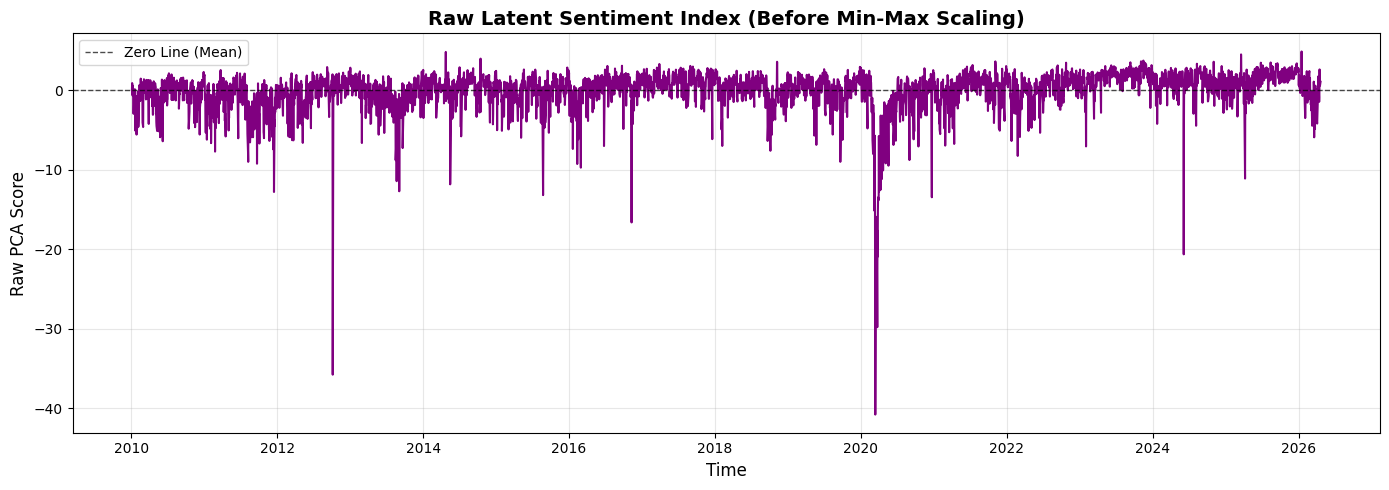

In [126]:
# Plotting the RAW Latent Sentiment Index 
plt.figure(figsize=(14, 5))

plt.plot(dates, df_pandas['Latent_Sentiment_Index'], color='purple', linewidth=1.5)

plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Zero Line (Mean)')

plt.title('Raw Latent Sentiment Index (Before Min-Max Scaling)', fontsize=14, fontweight='bold')
plt.ylabel('Raw PCA Score', fontsize=12)
plt.xlabel('Time', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

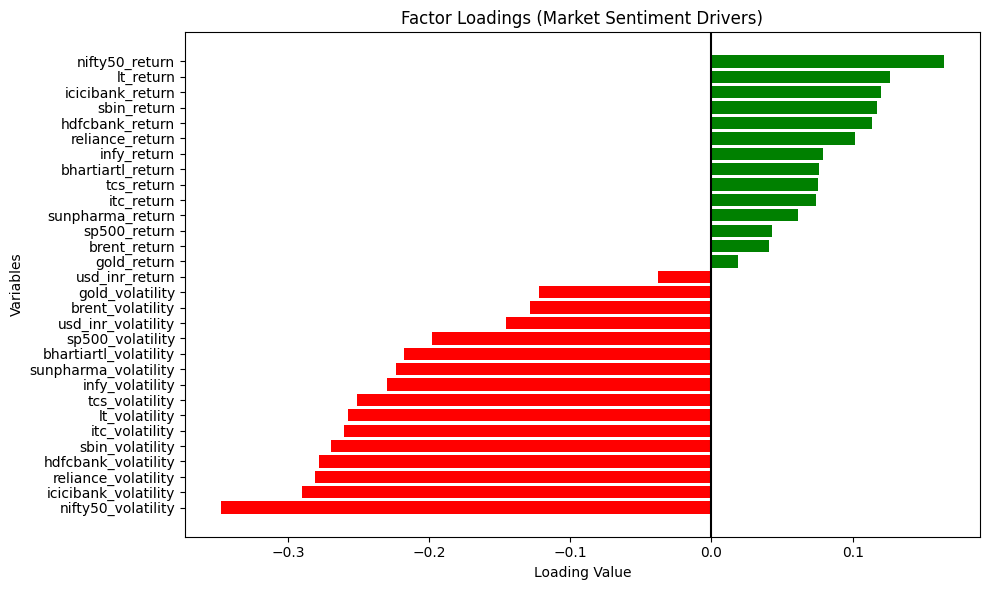

In [90]:

# Sort the loadings from lowest (Fear) to highest (Greed)
loadings_sorted = loadings.sort_values(by='PC1_Loading (Contribution)')


# Simple loop to set colors: Red if negative, Green if positive
colors = []
for weight in loadings_sorted['PC1_Loading (Contribution)']:
    if weight < 0:
        colors.append('red')  
    else:
        colors.append('green')


plt.figure(figsize=(10, 6))

plt.barh(loadings_sorted.index, loadings_sorted['PC1_Loading (Contribution)'], color=colors)

plt.axvline(0, color='black')
plt.title('Factor Loadings (Market Sentiment Drivers)')
plt.xlabel('Loading Value')
plt.ylabel('Variables')

plt.tight_layout()
plt.show()

---
# PART 2 — Time Series Analysis of Market Sentiment

## Step 1 — Prepare the Sentiment Series with Date Index

In [ ]:
import matplotlib.gridspec as gridspec
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera
from arch import arch_model
from pmdarima import auto_arima



In [127]:


sentiment = pd.Series(
    df_pandas['Latent_Sentiment_Index'].values,
    index=pd.to_datetime(dates.values),
    name='Latent_Sentiment_Index'
)

display(sentiment.describe().to_frame().T.round(4))

# sentiment = df_pandas['Latent_Sentiment_Index']      
# display(sentiment.describe().to_frame().T.round(4))

,count,mean,std,min,25%,50%,75%,max
Latent_Sentiment_Index,4252.0,-0.0,2.4985,-40.7996,-0.7645,0.5159,1.4467,4.8716


## Step 2 — Stationarity Tests (ADF + KPSS)

In [128]:
# ── ADF Test ──────────────────────────────────────────────────────────────────
adf_stat, adf_p, adf_lags, _, adf_cv, _ = adfuller(sentiment, autolag='AIC')

# ── KPSS Test ─────────────────────────────────────────────────────────────────
kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(sentiment, regression='c', nlags='auto')

stationarity_results = pd.DataFrame({
    'Test'      : ['ADF (H₀: Unit Root)',   'KPSS (H₀: Stationary)'],
    'Statistic' : [round(adf_stat, 4),       round(kpss_stat, 4)],
    'p-value'   : [round(adf_p, 4),          round(kpss_p, 4)],
    'Crit (5%)' : [round(adf_cv['5%'], 4),   round(kpss_cv['5%'], 4)],
    'Verdict'   : [
        'STATIONARY ✓' if adf_p < 0.05  else 'NON-STATIONARY ✗',
        'STATIONARY ✓' if kpss_p > 0.05 else 'NON-STATIONARY ✗'
    ]
})

display(stationarity_results)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_46456\3722392524.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(sentiment, regression='c', nlags='auto')


,Test,Statistic,p-value,Crit (5%),Verdict
0,ADF (H₀: Unit Root),-9.6332,0.00,-2.8622,STATIONARY ✓
1,KPSS (H₀: Stationary),1.2681,0.01,0.4630,NON-STATIONARY ✗


## Step 3 — Classical Time Series Decomposition

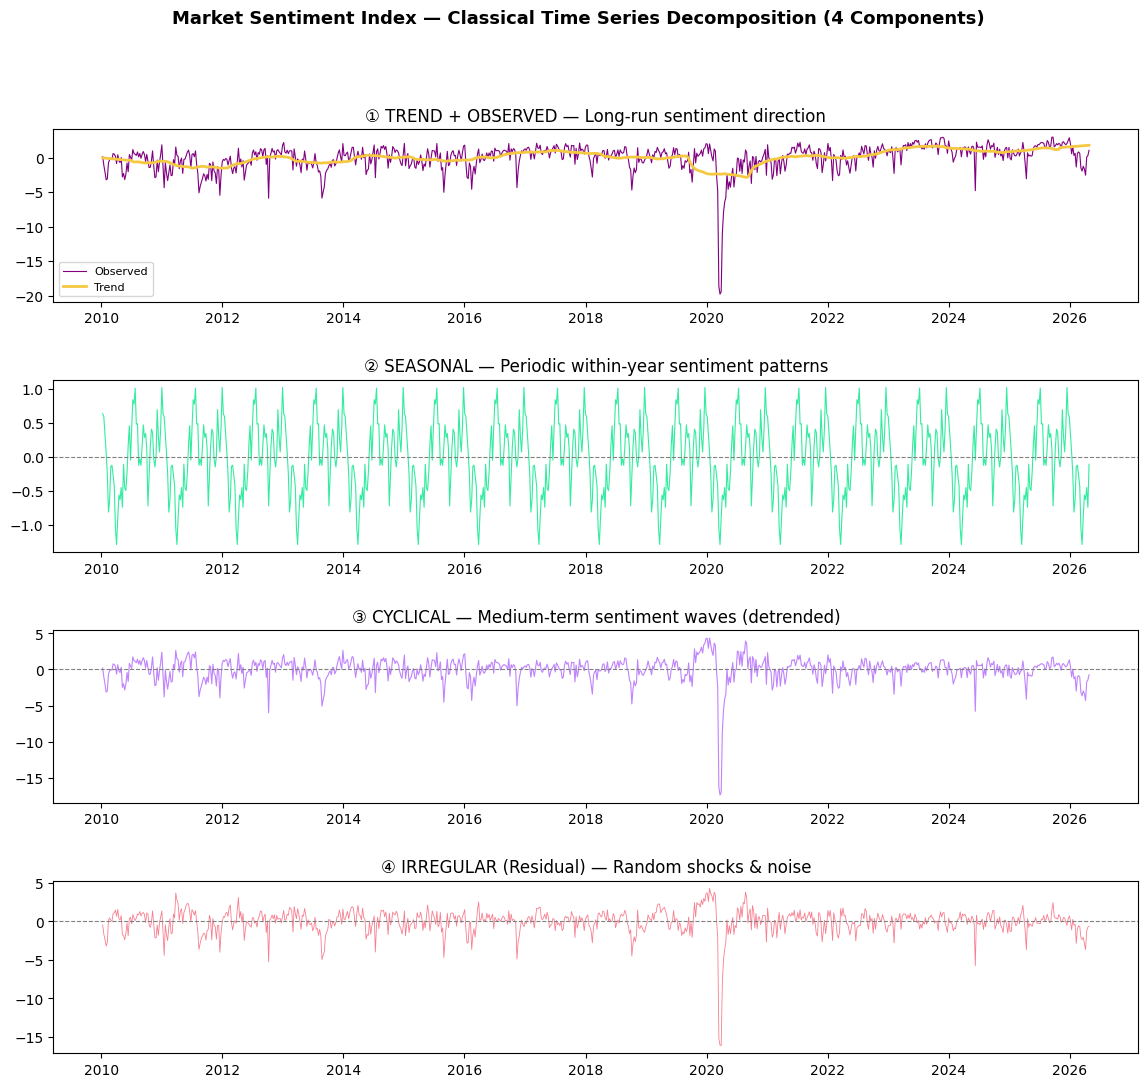

,Mean,Std Dev,Min,Max
Component,,,,
Trend,0.0395,0.9818,-2.8377,1.8026
Seasonal,-0.0080,0.5295,-1.2963,1.0245
Cyclical,-0.0375,1.7193,-17.3970,4.3625
Irregular,-0.0295,1.6357,-16.1297,4.2951


In [129]:
# Resample to weekly for cleaner seasonal decomposition (daily is too noisy)
sentiment_weekly = sentiment.resample('W').mean().interpolate()

decomp   = seasonal_decompose(sentiment_weekly, model='additive', period=52, extrapolate_trend='freq')
trend    = decomp.trend
seasonal = decomp.seasonal
resid    = decomp.resid
# Cyclical = detrended series (observed minus trend)
cyclical = sentiment_weekly - trend

fig = plt.figure(figsize=(14, 12))
fig.suptitle('Market Sentiment Index — Classical Time Series Decomposition (4 Components)',
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(4, 1, hspace=0.45)

ax1 = fig.add_subplot(gs[0])
ax1.plot(sentiment_weekly, color='purple',   lw=0.8, label='Observed')
ax1.plot(trend,            color='#f5c842',  lw=2,   label='Trend')
ax1.set_title('① TREND + OBSERVED — Long-run sentiment direction')
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[1])
ax2.plot(seasonal, color='#34eca0', lw=0.8)
ax2.axhline(0, color='grey', lw=0.8, ls='--')
ax2.set_title('② SEASONAL — Periodic within-year sentiment patterns')

ax3 = fig.add_subplot(gs[2])
ax3.plot(cyclical, color='#c084fc', lw=0.8)
ax3.axhline(0, color='grey', lw=0.8, ls='--')
ax3.set_title('③ CYCLICAL — Medium-term sentiment waves (detrended)')

ax4 = fig.add_subplot(gs[3])
ax4.plot(resid, color='#f55f74', lw=0.6, alpha=0.8)
ax4.axhline(0, color='grey', lw=0.8, ls='--')
ax4.set_title('④ IRREGULAR (Residual) — Random shocks & noise')

plt.tight_layout()
plt.show()

decomp_summary = pd.DataFrame({
    'Component' : ['Trend',         'Seasonal',         'Cyclical',         'Irregular'],
    'Mean'      : [trend.mean(),     seasonal.mean(),     cyclical.mean(),     resid.dropna().mean()],
    'Std Dev'   : [trend.std(),      seasonal.std(),      cyclical.std(),      resid.dropna().std()],
    'Min'       : [trend.min(),      seasonal.min(),      cyclical.min(),      resid.dropna().min()],
    'Max'       : [trend.max(),      seasonal.max(),      cyclical.max(),      resid.dropna().max()],
}).set_index('Component').round(4)

display(decomp_summary)

## Step 4 — ACF & PACF Analysis

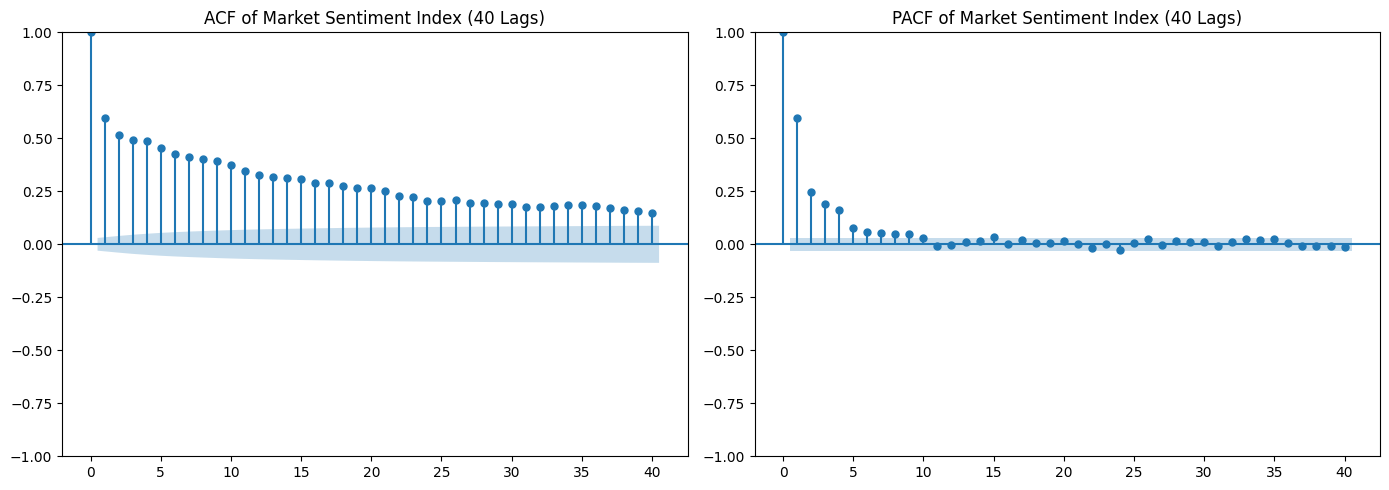

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf( sentiment.dropna(), lags=40, ax=axes[0], title='ACF of Market Sentiment Index (40 Lags)')
plot_pacf(sentiment.dropna(), lags=40, ax=axes[1], title='PACF of Market Sentiment Index (40 Lags)', method='ywm')

plt.tight_layout()
plt.show()

## Step 5 — ARIMA Model Selection (auto_arima)

In [131]:
# Train-Test split: 90% train, 10% test
split_idx  = int(len(sentiment) * 0.9)
train      = sentiment.iloc[:split_idx]
test       = sentiment.iloc[split_idx:]

split_info = pd.DataFrame({
    'Split'        : ['Train', 'Test'],
    'Observations' : [len(train), len(test)],
    'Start'        : [train.index[0].date(), test.index[0].date()],
    'End'          : [train.index[-1].date(), test.index[-1].date()]
})
display(split_info)

# auto_arima on train set — sentiment is I(0), so d=0 is fixed
stepwise_model = auto_arima(
    train,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=0,
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore'
)

best_order = stepwise_model.order
display(pd.DataFrame({
    'Best Order (p,d,q)' : [str(best_order)],
    'AIC'                : [round(stepwise_model.aic(), 4)],
    'BIC'                : [round(stepwise_model.bic(), 4)]
}))

,Split,Observations,Start,End
0,Train,3826,2010-01-04,2024-08-29
1,Test,426,2024-08-30,2026-04-20


,"Best Order (p,d,q)",AIC,BIC
0,"(5, 0, 1)",15829.1801,15872.9272


## Step 6 — ARIMA Model Fit & Summary

In [132]:
# Fit the selected ARIMA model on training data
arima_fit = ARIMA(train.values, order=best_order).fit()
display(arima_fit.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 3826
Model:                 ARIMA(5, 0, 1)   Log Likelihood               -7907.484
Date:                Tue, 28 Apr 2026   AIC                          15830.969
Time:                        01:18:22   BIC                          15880.965
Sample:                             0   HQIC                         15848.731
                               - 3826                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0991      0.282     -0.352      0.725      -0.651       0.453
ar.L1          1.1536      0.033     34.643      0.000       1.088       1.219
ar.L2         -0.1698      0.016    -10.814      0.000      -0.201      -0.139
ar.L3          0.0061      0.018      0.342      0.732      -0.029       0.041
ar.L4          0.0356      0.017      2.144      0.032       0.003       0.068
ar.L5         -0.0535      0.014     -3.950      0.000      -0.080      -0.027
ma.L1         -0.8039      0.032    -24.952      0.000      -0.867      -0.741
sigma2         3.6525      0.019    191.908      0.000       3.615       3.690
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            616236.34
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.97   Skew:                            -4.63
Prob(H) (two-sided):                  0.63   Kurtosis:                        64.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Step 7 — Residual Diagnostics (Ljung-Box · ARCH · Jarque-Bera)

,lb_stat,lb_pvalue
10,4.6503,0.9133
20,12.8640,0.8831
30,23.6340,0.7883


,Test,Statistic,p-value,Interpretation
0,Engle's ARCH (nlags=10),69.4635,0.0,ARCH effects present → GARCH needed
1,Jarque-Bera Normality,616196.4138,0.0,Residuals non-normal (fat tails)


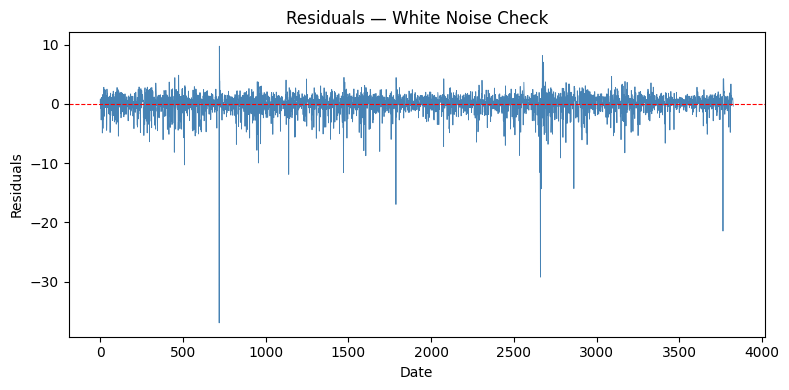

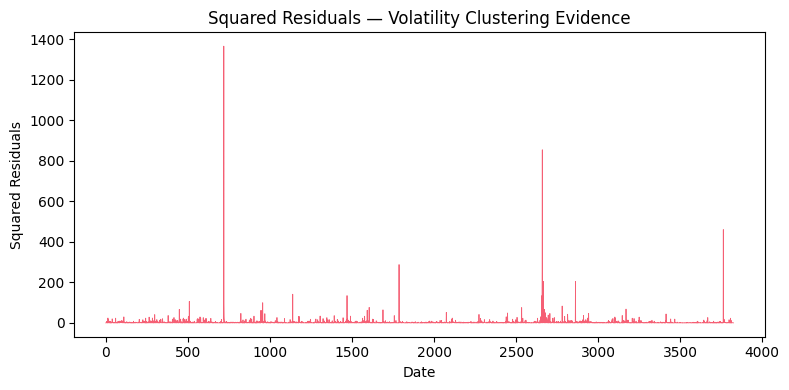

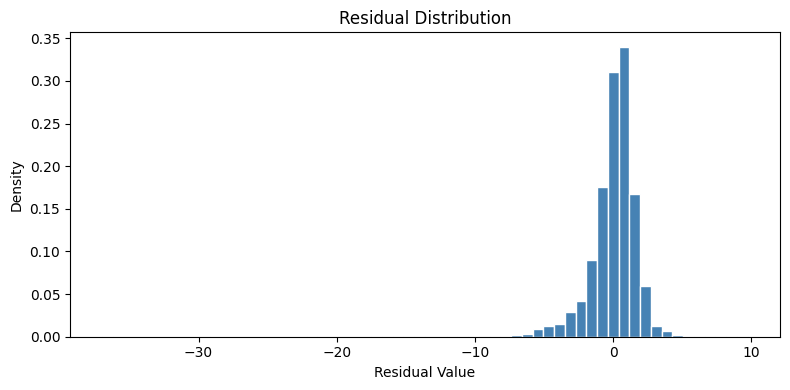

In [133]:
residuals = arima_fit.resid

# ── TEST 1: Ljung-Box — tests for autocorrelation in residuals ────────────────
lb_result = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
display(lb_result.round(4))

# ── TEST 2: Engle's ARCH — tests for volatility clustering ───────────────────
arch_lm_stat, arch_lm_p, _, _ = het_arch(residuals, nlags=10)

# ── TEST 3: Jarque-Bera — tests residual normality ───────────────────────────
jb_stat, jb_p = jarque_bera(residuals)

diag_summary = pd.DataFrame({
    'Test'        : ["Engle's ARCH (nlags=10)", 'Jarque-Bera Normality'],
    'Statistic'   : [round(arch_lm_stat, 4),     round(jb_stat, 4)],
    'p-value'     : [round(arch_lm_p, 6),         round(jb_p, 6)],
    'Interpretation' : [
        'ARCH effects present → GARCH needed' if arch_lm_p < 0.05 else 'No ARCH effects',
        'Residuals non-normal (fat tails)'    if jb_p < 0.05     else 'Residuals approximately normal'
    ]
})
display(diag_summary)

# ── Residual Plots ────────────────────────────────────────────────────────────
# --- GRAPH 1: Residuals ---
plt.figure(figsize=(8, 4))
plt.plot(residuals, color='steelblue', lw=0.6)
plt.axhline(0, color='red', ls='--', lw=0.8)
plt.title('Residuals — White Noise Check')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

# --- GRAPH 2: Squared Residuals ---
plt.figure(figsize=(8, 4))
plt.plot(residuals**2, color='#f55f74', lw=0.6)
plt.title('Squared Residuals — Volatility Clustering Evidence')
plt.xlabel('Date')
plt.ylabel('Squared Residuals')
plt.tight_layout()
plt.show()

# --- GRAPH 3: Residual Distribution ---
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=60, color='steelblue', edgecolor='white', density=True)
plt.title('Residual Distribution')
plt.xlabel('Residual Value')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

## Step 8 — Forecast vs Actuals

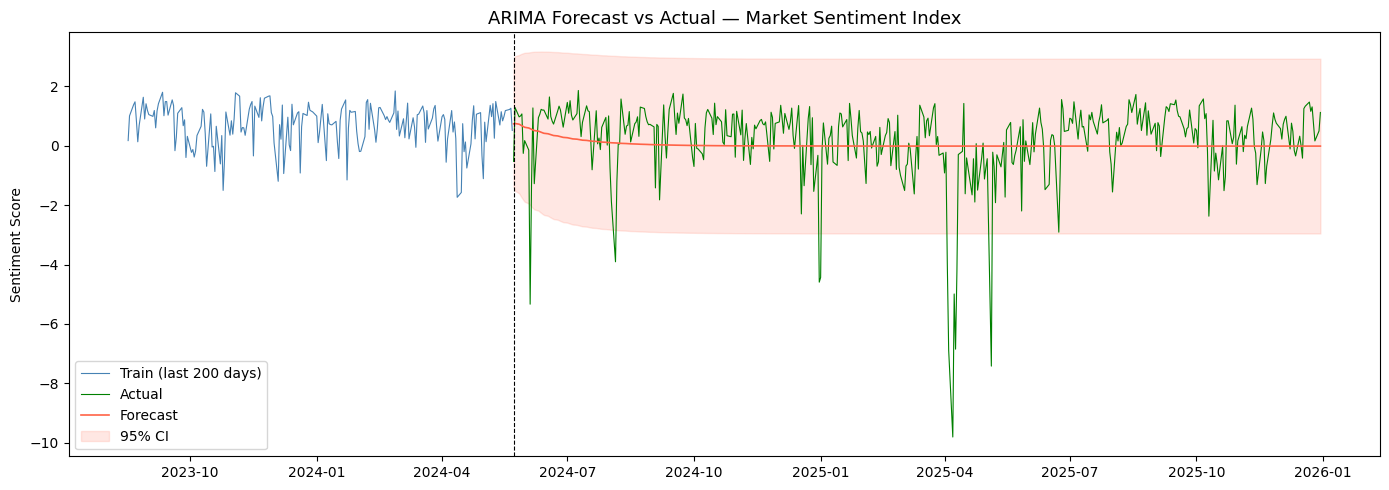

In [24]:
forecast_obj  = arima_fit.get_forecast(steps=len(test))
forecast_mean = pd.Series(forecast_obj.predicted_mean, index=test.index)
ci_raw        = forecast_obj.conf_int(alpha=0.05)
# conf_int returns ndarray when model is fit on .values; wrap it safely
ci_df         = pd.DataFrame(
    np.array(ci_raw).reshape(-1, 2),
    index=test.index, columns=['lower', 'upper']
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.iloc[-200:],  color='steelblue', lw=0.8,  label='Train (last 200 days)')
ax.plot(test,               color='green',     lw=0.8,  label='Actual')
ax.plot(forecast_mean,      color='tomato',    lw=1.2,  label='Forecast')
ax.fill_between(ci_df.index, ci_df['lower'], ci_df['upper'],
                color='tomato', alpha=0.15, label='95% CI')
ax.axvline(test.index[0], color='black', ls='--', lw=0.8)
ax.set_title('ARIMA Forecast vs Actual — Market Sentiment Index', fontsize=13)
ax.set_ylabel('Sentiment Score')
ax.legend()
plt.tight_layout()
plt.show()

## Step 9 — Forecast Evaluation Metrics

In [25]:
errors   = test.values - forecast_mean.values

mae      = np.mean(np.abs(errors))
rmse     = np.sqrt(np.mean(errors**2))
mape     = np.mean(np.abs(errors / test.values)) * 100

# Directional accuracy: did the forecast get the sign of daily change right?
actual_dir   = np.sign(np.diff(test.values))
forecast_dir = np.sign(np.diff(forecast_mean.values))
dir_acc      = np.mean(actual_dir == forecast_dir) * 100

metrics = pd.DataFrame({
    'Metric'  : ['MAE', 'RMSE', 'MAPE (%)', 'Directional Accuracy (%)'],
    'Value'   : [round(mae, 4), round(rmse, 4), round(mape, 2), round(dir_acc, 2)]
})
display(metrics)

,Metric,Value
0,MAE,0.8796
1,RMSE,1.3067
2,MAPE (%),102.7400
3,Directional Accuracy (%),50.1200


## Step 10 — Runs Test (Market Randomness / Random Walk Hypothesis)

In [26]:
from scipy import stats

signs  = np.sign(sentiment.values)
signs  = signs[signs != 0]                          # remove exact-zero days
n_pos  = (signs > 0).sum()
n_neg  = (signs < 0).sum()
n      = len(signs)
runs   = 1 + np.sum(signs[1:] != signs[:-1])        # count sign changes

mu_r   = (2 * n_pos * n_neg) / n + 1
var_r  = (2 * n_pos * n_neg * (2*n_pos*n_neg - n)) / (n**2 * (n - 1))
z_r    = (runs - mu_r) / np.sqrt(var_r)
p_r    = 2 * (1 - stats.norm.cdf(abs(z_r)))

runs_result = pd.DataFrame({
    'Metric'  : ['Total Observations', 'Up days (+)', 'Down days (−)',
                 'Observed Runs', 'Expected Runs', 'Z-Statistic', 'p-value', 'Verdict'],
    'Value'   : [n, n_pos, n_neg, runs, round(mu_r, 1), round(z_r, 4), round(p_r, 4),
                 'REJECT RWH: non-random pattern' if p_r < 0.05 else 'Fail to reject RWH']
})
display(runs_result)

,Metric,Value
0,Total Observations,4171
1,Up days (+),2620
2,Down days (−),1551
3,Observed Runs,1220
4,Expected Runs,1949.5
5,Z-Statistic,-14292.8088
6,p-value,0.0
7,Verdict,REJECT RWH: non-random pattern


## Step 11 — Variance Ratio Test

In [27]:
def variance_ratio(series, k):
    """VR(k) = Var(k-period returns) / (k × Var(1-period return)).
    VR ≈ 1 → Random Walk | VR > 1 → momentum | VR < 1 → mean reversion."""
    r    = series.values
    n    = len(r)
    mu   = r.mean()
    var1 = np.sum((r - mu)**2) / (n - 1)
    rk   = np.array([np.sum(r[i:i+k]) for i in range(n - k + 1)])
    vark = np.sum((rk - k * mu)**2) / ((n - k) * (1 + (k - 1)))
    return vark / var1

vr_results = pd.DataFrame([
    {
        'Horizon k' : k,
        'VR(k)'     : round(variance_ratio(sentiment, k), 4),
        'Signal'    : '≈ Random Walk' if 0.95 <= variance_ratio(sentiment, k) <= 1.05
                      else ('Momentum ↑' if variance_ratio(sentiment, k) > 1.05 else 'Mean Reversion ↓')
    }
    for k in [2, 4, 5, 10, 20]
])
display(vr_results)

,Horizon k,VR(k),Signal
0,2,1.6259,Momentum ↑
1,4,2.7458,Momentum ↑
2,5,3.2645,Momentum ↑
3,10,5.6100,Momentum ↑
4,20,9.4894,Momentum ↑


## Step 12 — GARCH(1,1) Volatility Model

,Parameter,Value
0,μ (mean),36.221874
1,ω (omega),1557.223031
2,α[1] — ARCH / Shock Impact,0.227591
3,β[1] — GARCH / Volatility Persistence,0.693402
4,α + β (proximity to 1 = long memory),0.920993
5,Volatility Half-Life (days),8.420000


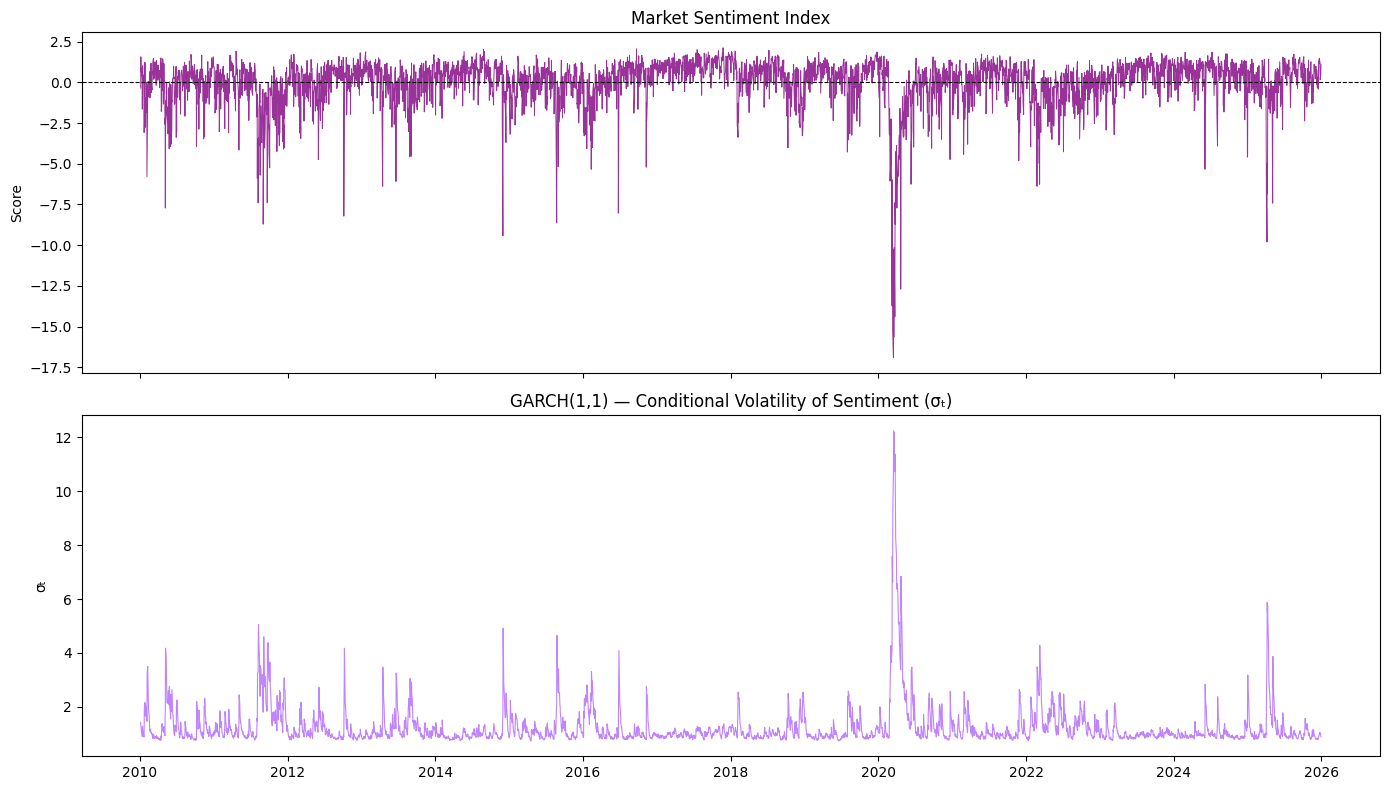

In [28]:
# Scale by 100 for numerical stability (standard practice)
garch_model = arch_model(sentiment * 100, vol='Garch', p=1, q=1, dist='normal')
garch_fit   = garch_model.fit(update_freq=0, disp='off')

p = garch_fit.params
garch_summary = pd.DataFrame({
    'Parameter'     : ['μ (mean)', 'ω (omega)', 'α[1] — ARCH / Shock Impact',
                       'β[1] — GARCH / Volatility Persistence',
                       'α + β  (proximity to 1 = long memory)',
                       'Volatility Half-Life (days)'],
    'Value'         : [
        round(p['mu'],        6),
        round(p['omega'],     6),
        round(p['alpha[1]'],  6),
        round(p['beta[1]'],   6),
        round(p['alpha[1]'] + p['beta[1]'], 6),
        round(np.log(0.5) / np.log(p['alpha[1]'] + p['beta[1]']), 2)
    ]
})
display(garch_summary)

# Conditional volatility plot
cond_vol = garch_fit.conditional_volatility / 100
vol_index = sentiment.index[len(sentiment.index) - len(cond_vol):]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(sentiment, color='purple', lw=0.7, alpha=0.8)
axes[0].axhline(0, color='black', ls='--', lw=0.8)
axes[0].set_title('Market Sentiment Index')
axes[0].set_ylabel('Score')

axes[1].plot(vol_index, cond_vol, color='#c084fc', lw=0.8)
axes[1].set_title('GARCH(1,1) — Conditional Volatility of Sentiment (σₜ)')
axes[1].set_ylabel('σₜ')

plt.tight_layout()
plt.show()

## Step 13 — 30-Day Future Forecast

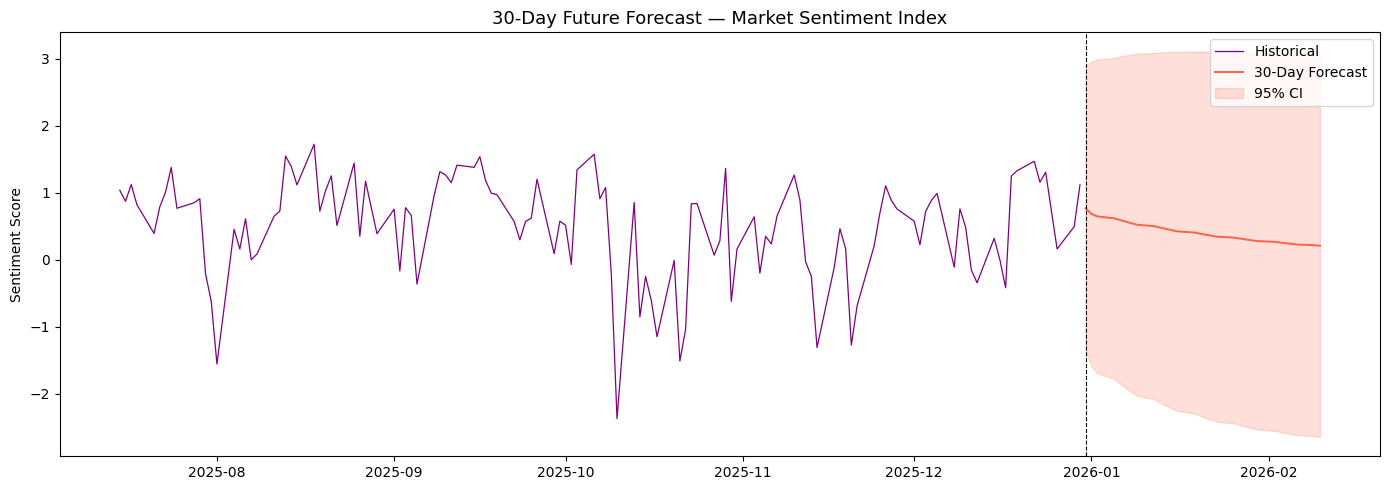

,Date,Forecast,Lower 95%,Upper 95%
0,2025-12-31,0.7669,-1.3589,2.8928
1,2026-01-01,0.6828,-1.5904,2.9560
2,2026-01-02,0.6455,-1.6954,2.9865
3,2026-01-05,0.6173,-1.7762,3.0108
4,2026-01-06,0.5915,-1.8481,3.0312
5,2026-01-07,0.5671,-1.9139,3.0481
6,2026-01-08,0.5437,-1.9747,3.0620
7,2026-01-09,0.5212,-2.0309,3.0734
8,2026-01-12,0.4998,-2.0831,3.0826
9,2026-01-13,0.4792,-2.1316,3.0899


In [29]:
# Re-fit ARIMA on the full series for production forecast
final_arima   = ARIMA(sentiment.values, order=best_order).fit()

future_obj    = final_arima.get_forecast(steps=30)
future_mean   = future_obj.predicted_mean

last_date     = sentiment.index[-1]
future_idx    = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=30)

future_mean_s = pd.Series(future_mean, index=future_idx)
future_ci_raw = future_obj.conf_int(alpha=0.05)
future_ci_df  = pd.DataFrame(
    np.array(future_ci_raw).reshape(-1, 2),
    index=future_idx, columns=['lower', 'upper']
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sentiment.iloc[-120:], color='purple', lw=0.9, label='Historical')
ax.plot(future_mean_s,         color='tomato',  lw=1.4, label='30-Day Forecast')
ax.fill_between(future_ci_df.index,
                future_ci_df['lower'], future_ci_df['upper'],
                color='tomato', alpha=0.2, label='95% CI')
ax.axvline(future_idx[0], color='black', ls='--', lw=0.8)
ax.set_title('30-Day Future Forecast — Market Sentiment Index', fontsize=13)
ax.set_ylabel('Sentiment Score')
ax.legend()
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    'Date'       : future_idx,
    'Forecast'   : future_mean_s.values.round(4),
    'Lower 95%'  : future_ci_df['lower'].values.round(4),
    'Upper 95%'  : future_ci_df['upper'].values.round(4)
}).head(10))